In [1]:
!pip install roboflow 

  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
Using cached idna-3.7-py3-none-any.whl (66 kB)
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


IMPORTING DATA FROM ROBOFLOW USING API

In [2]:


from roboflow import Roboflow
rf = Roboflow(api_key="mSlY0ua0UU8RVYWLAUWb")
project = rf.workspace("hunau-csecl").project("face-detection-5w6i9")
version = project.version(1)
dataset = version.download("yolov8")
                
                

loading Roboflow workspace...
loading Roboflow project...


In [34]:
!pip install numpy==1.26.4

TRAINING YOLO V8 MODEL

In [3]:
%pwd

import os
from ultralytics import YOLO
import numpy 
import torch


model = YOLO("yolov8s.pt")
training_result = model.train(data="Face-Detection-1/data.yaml", epochs=80, batch = 4)



Ultralytics 8.3.233  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Face-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train20, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=

YOLOv8 MODEL EVALUATION

In [4]:
result = model.val(data = "Face-Detection-1/data.yaml")



Ultralytics 8.3.233  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1050, 4096MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 52.215.0 MB/s, size: 48.2 KB)
val: Scanning C:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\valid\labels.cache... 97 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 97/97 32.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.6s/it 25.4s2.5ss
                   all         97        155      0.954      0.884      0.966      0.849
Speed: 56.7ms preprocess, 30.1ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to C:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\runs\detect\val4


In [5]:

print("Precision:", result.box.ap[0])
print("Recall: ", result.box.r[0])
print("F1 score:", result.box.f1)


Precision: 0.8491178593025795
Recall:  0.8838709677419355
F1 score: [    0.91757]


In [83]:
from IPython.display import Image, display
resultData = "runs/detect/train20/"
resultData_11 = "runs/detect/train22/"

<h3>Dislaying Trained Images Yolov8<h3>

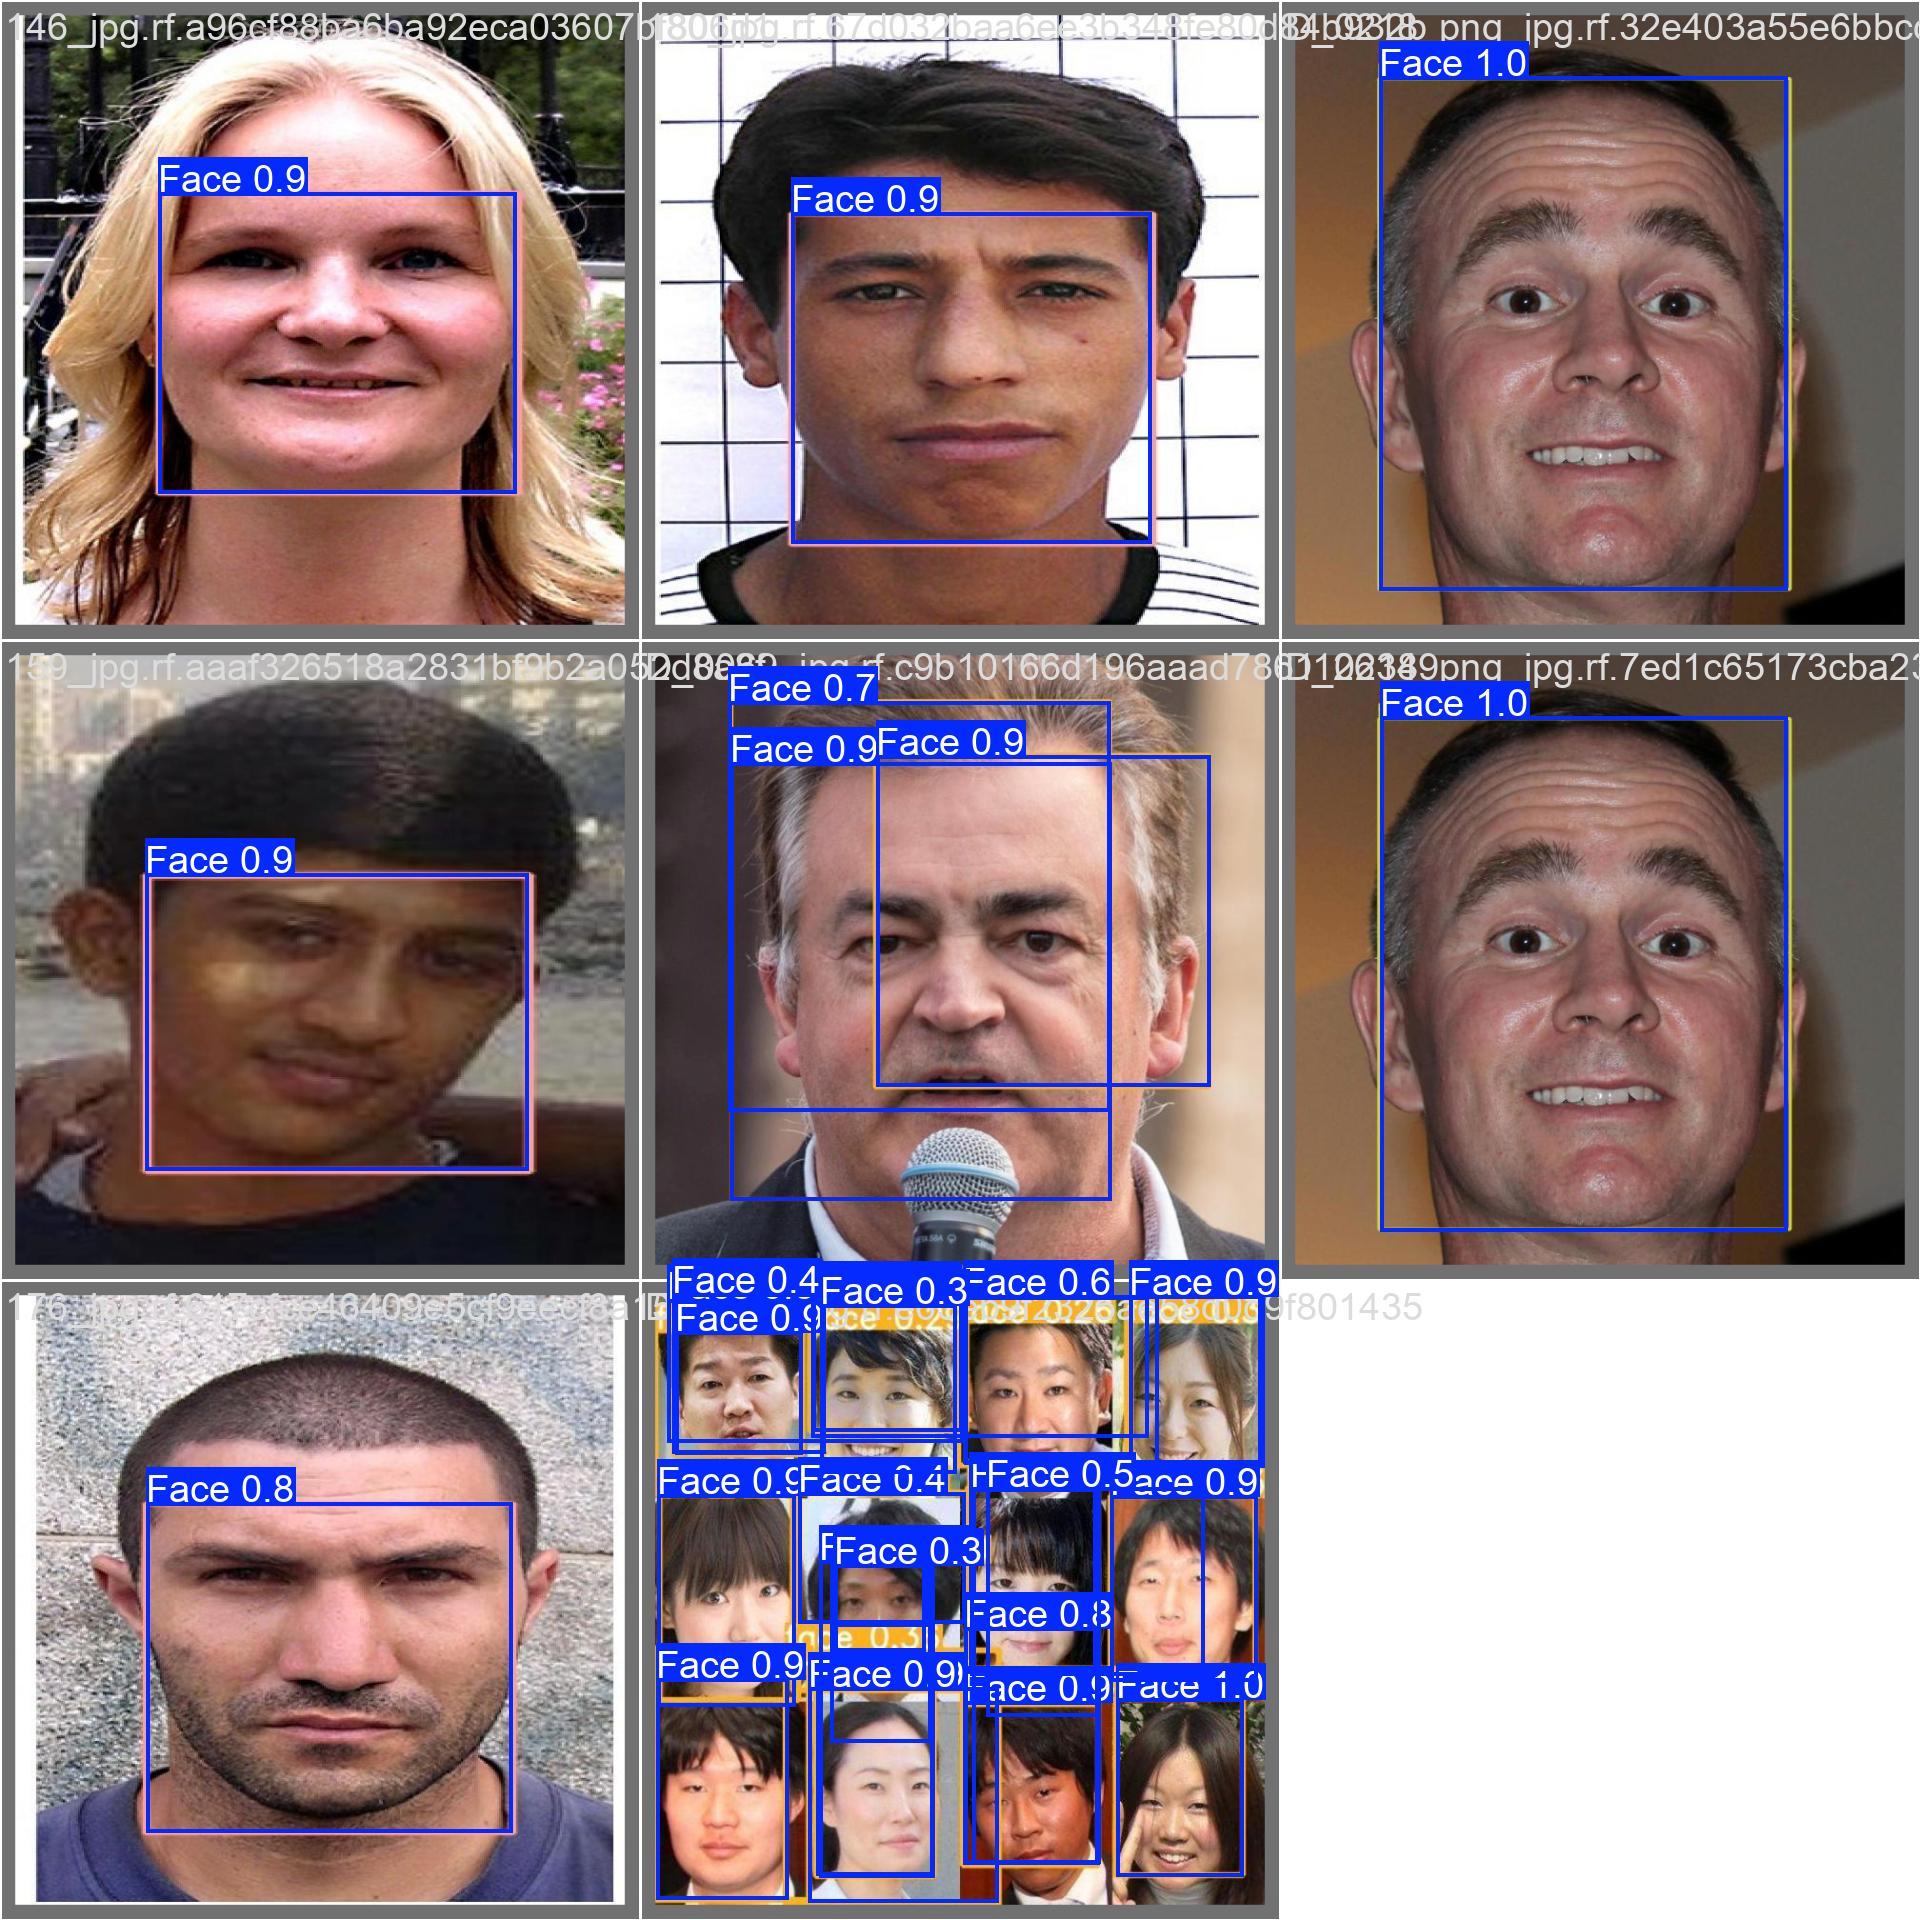

In [57]:
Image(filename=f"{resultData}val_batch1_pred.jpg")

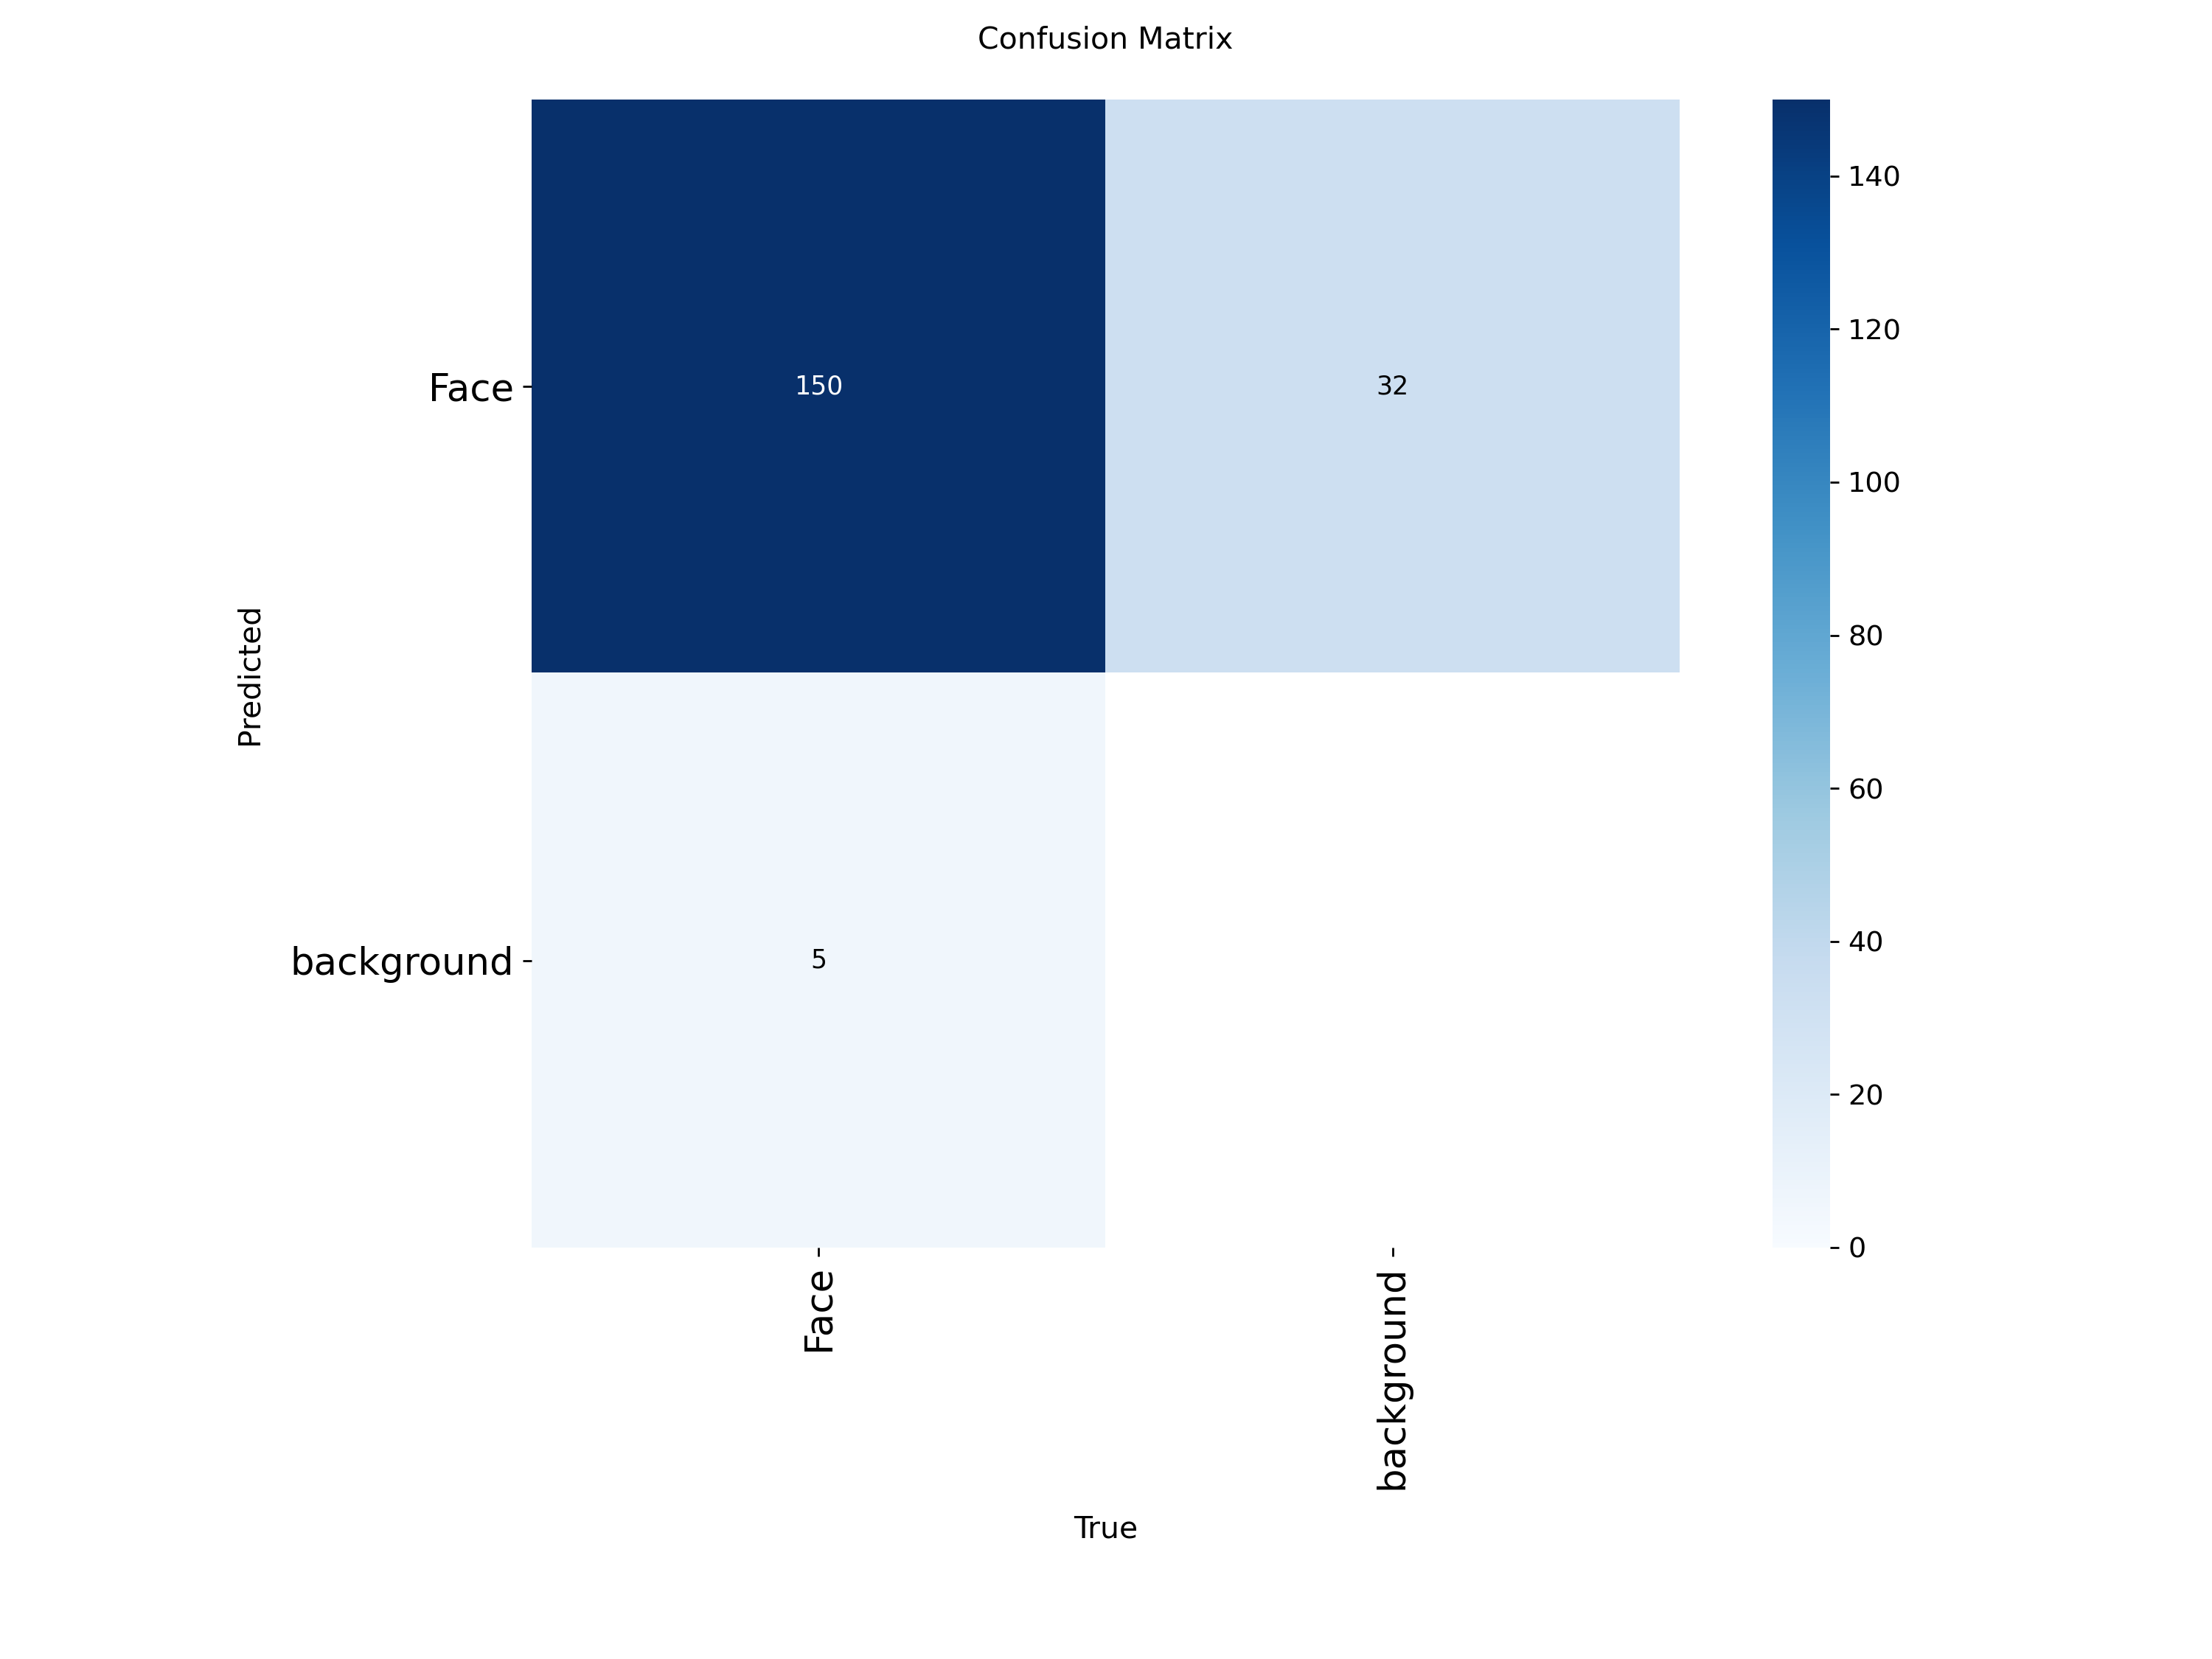

In [47]:
Image(filename=f"{resultData}confusion_matrix.png")

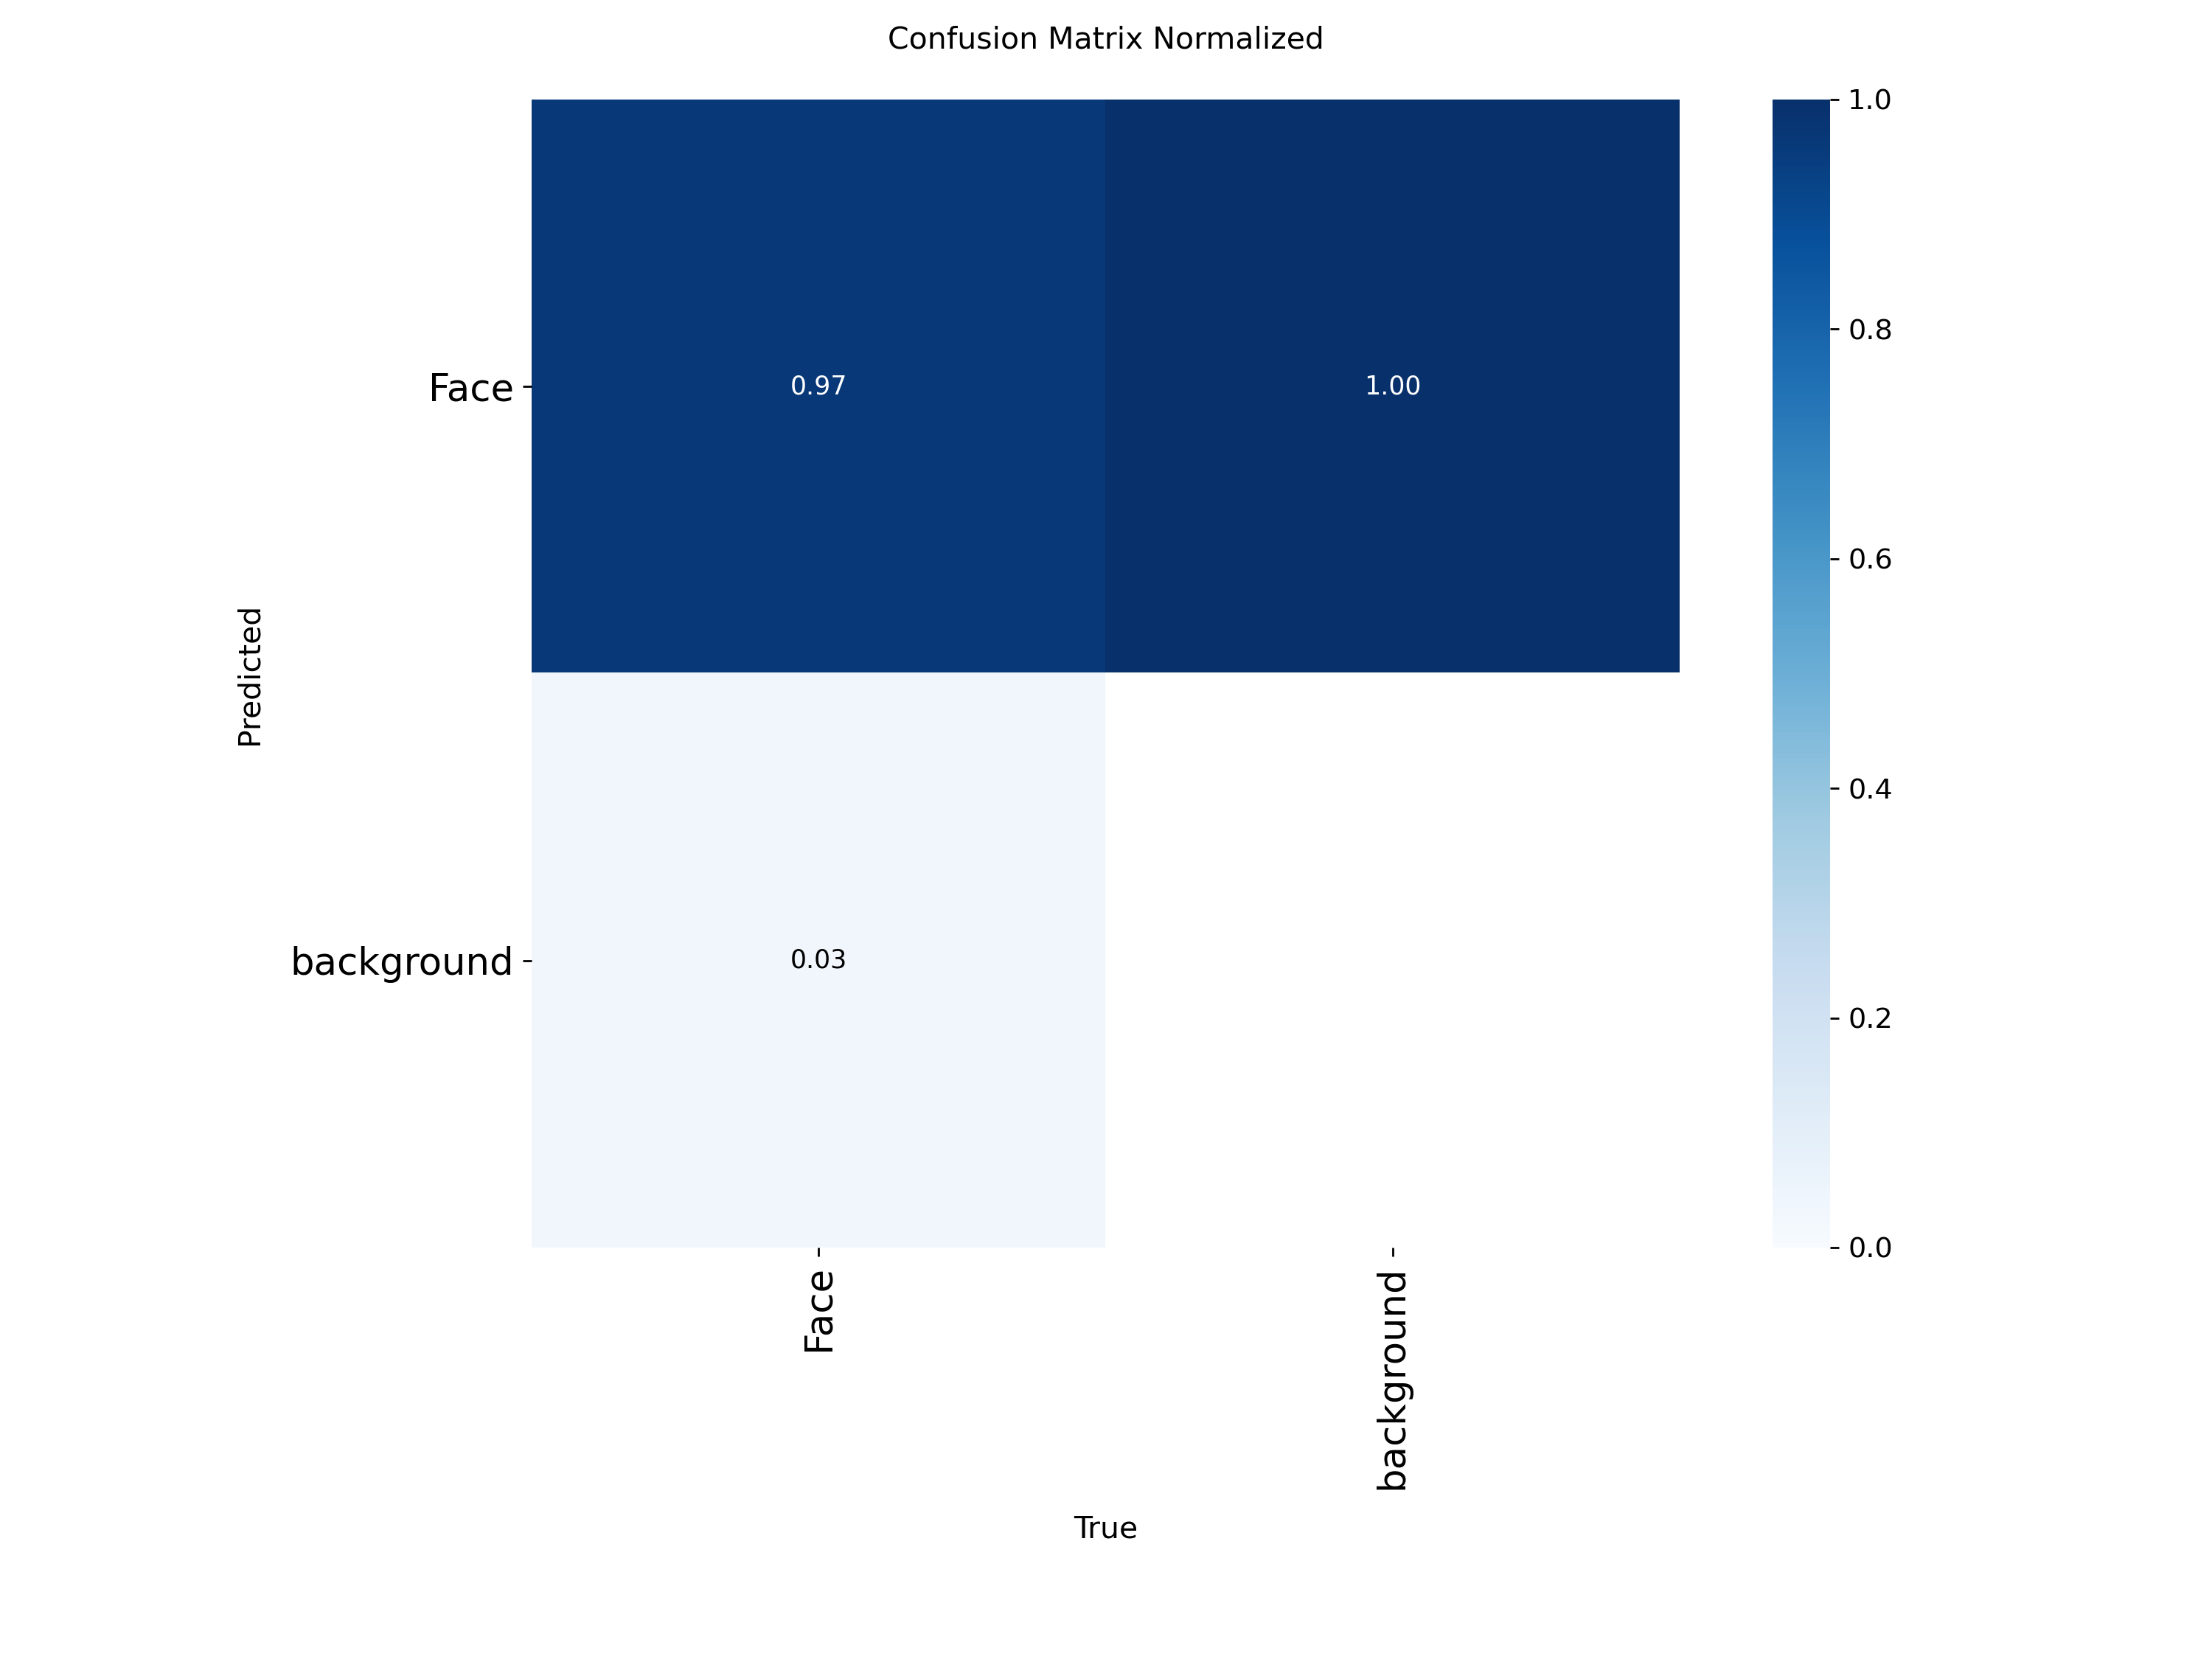

In [15]:
Image(filename=f"{resultData}confusion_matrix_normalized.png")


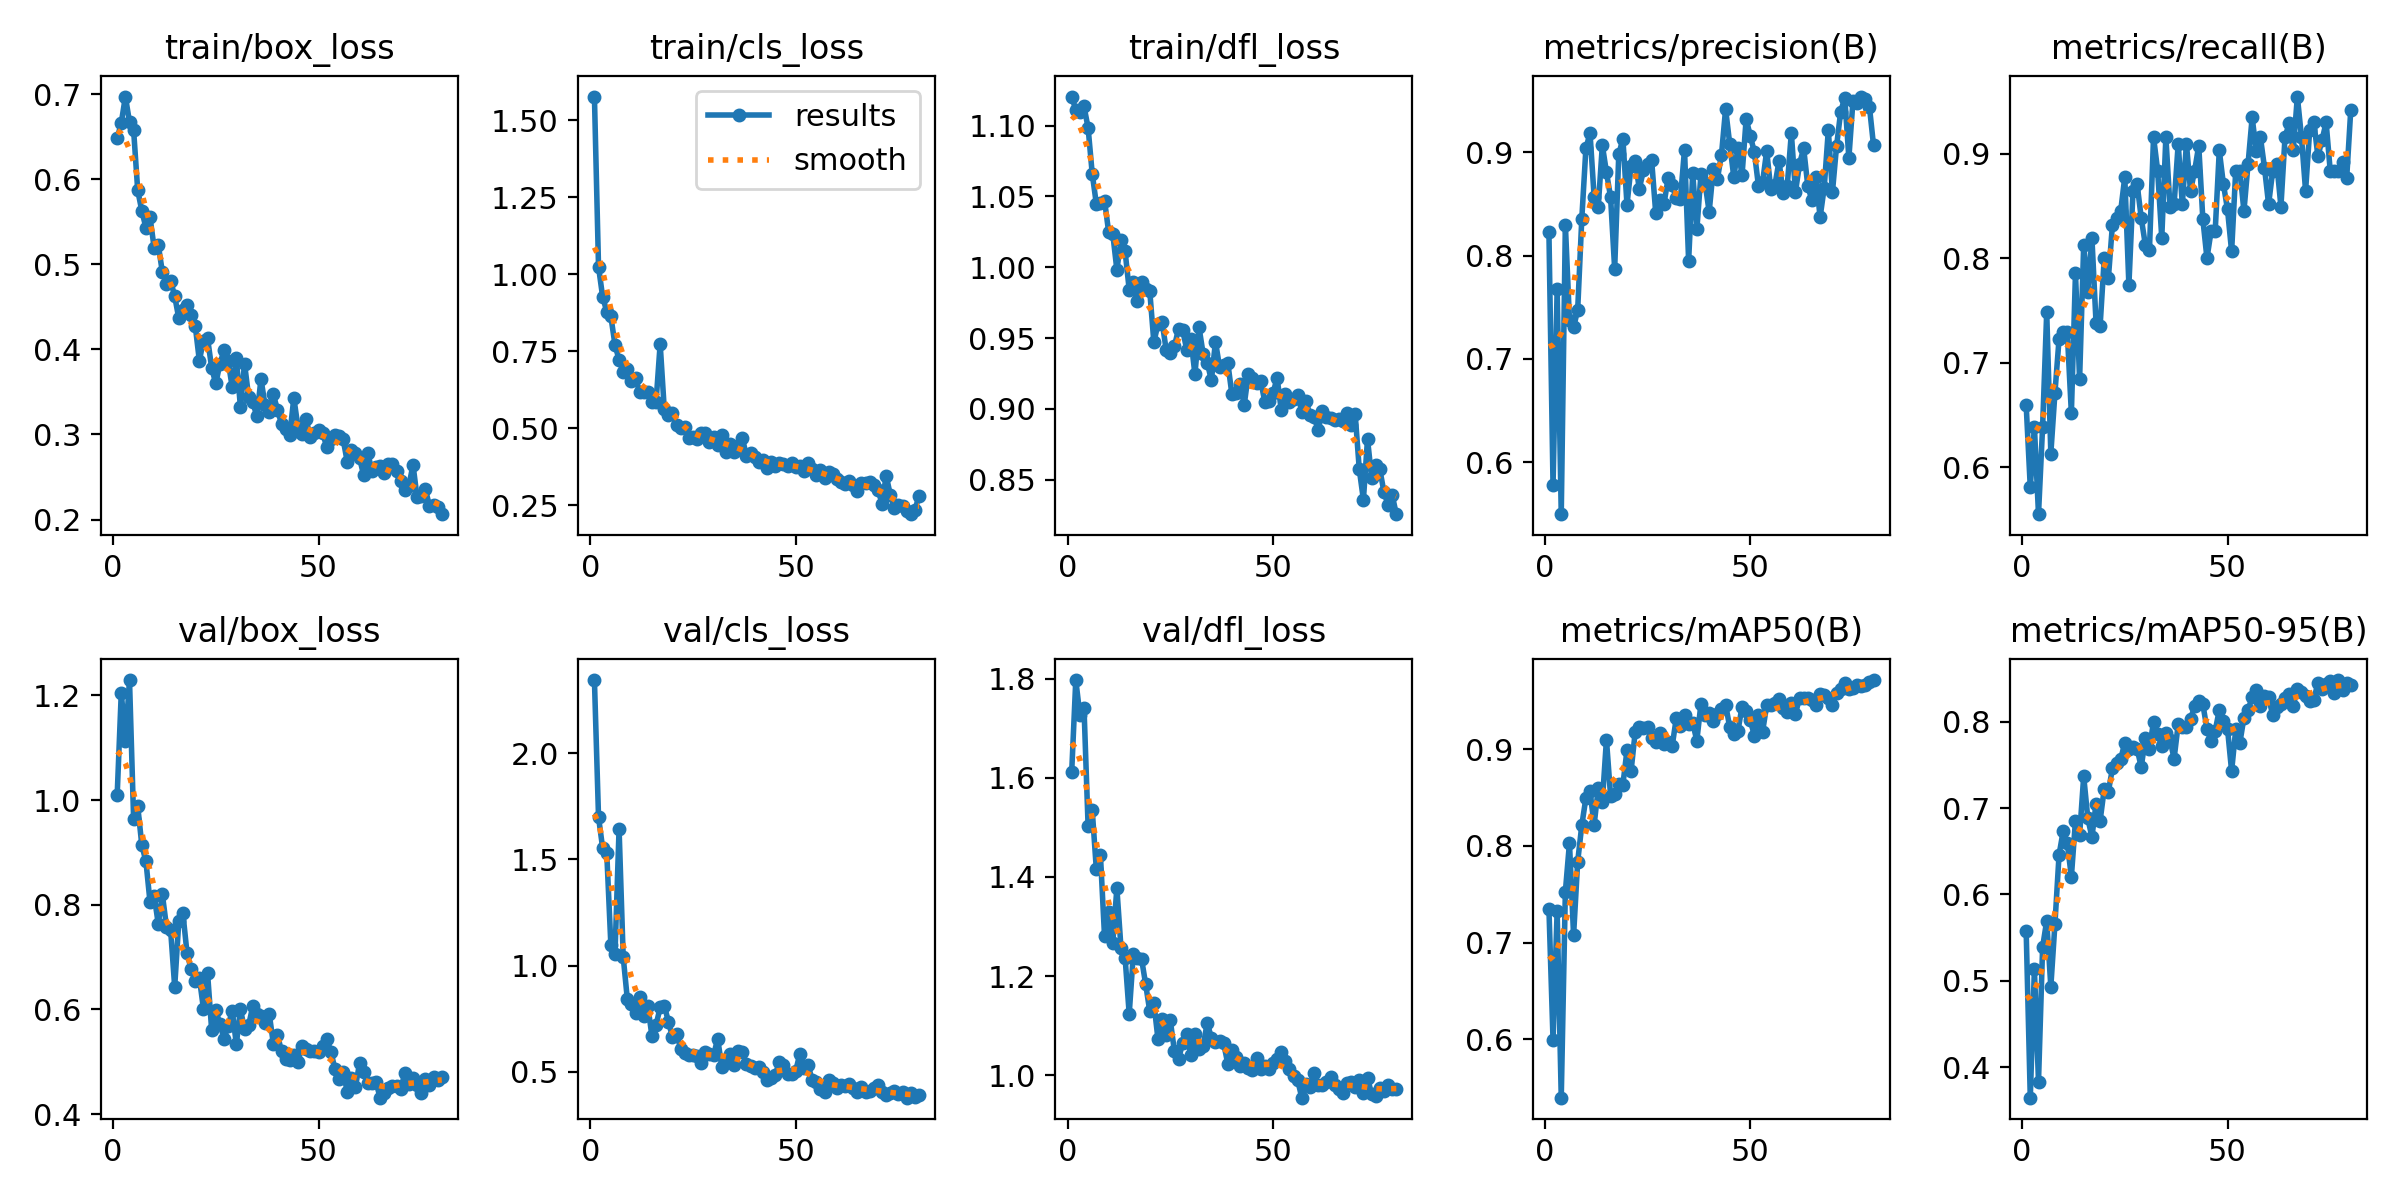

In [16]:
Image(filename=f"{resultData}results.png")

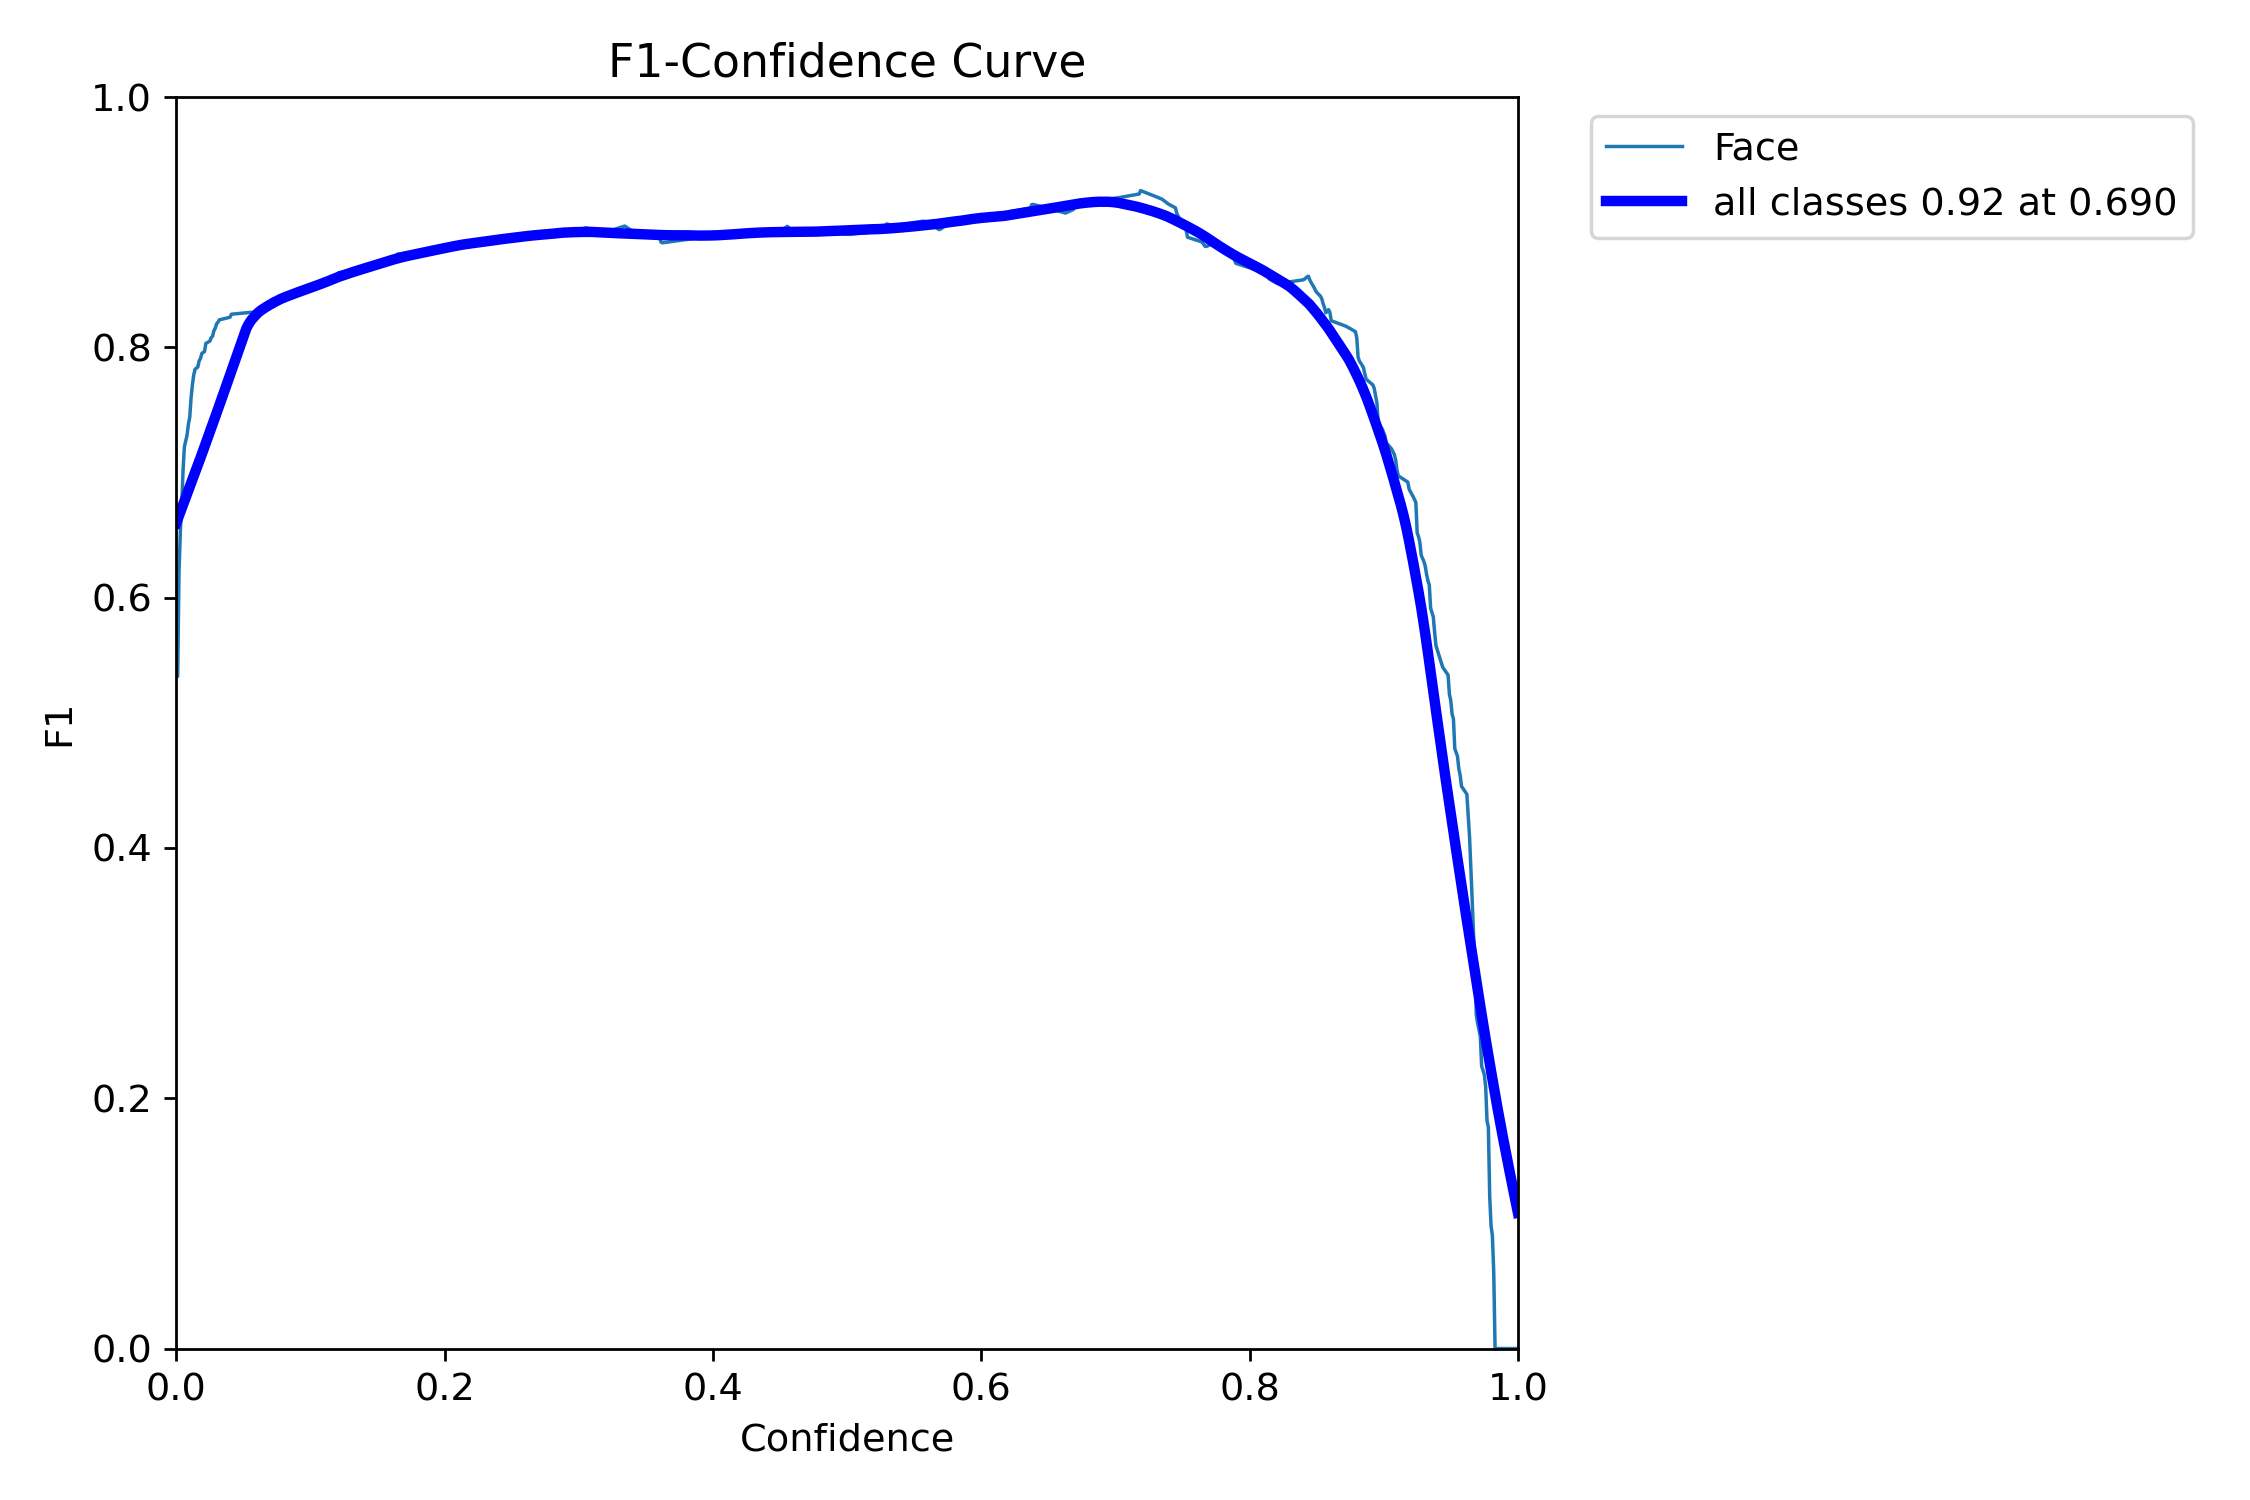

In [45]:
Image(filename=f"{resultData}BoxF1_curve.png")

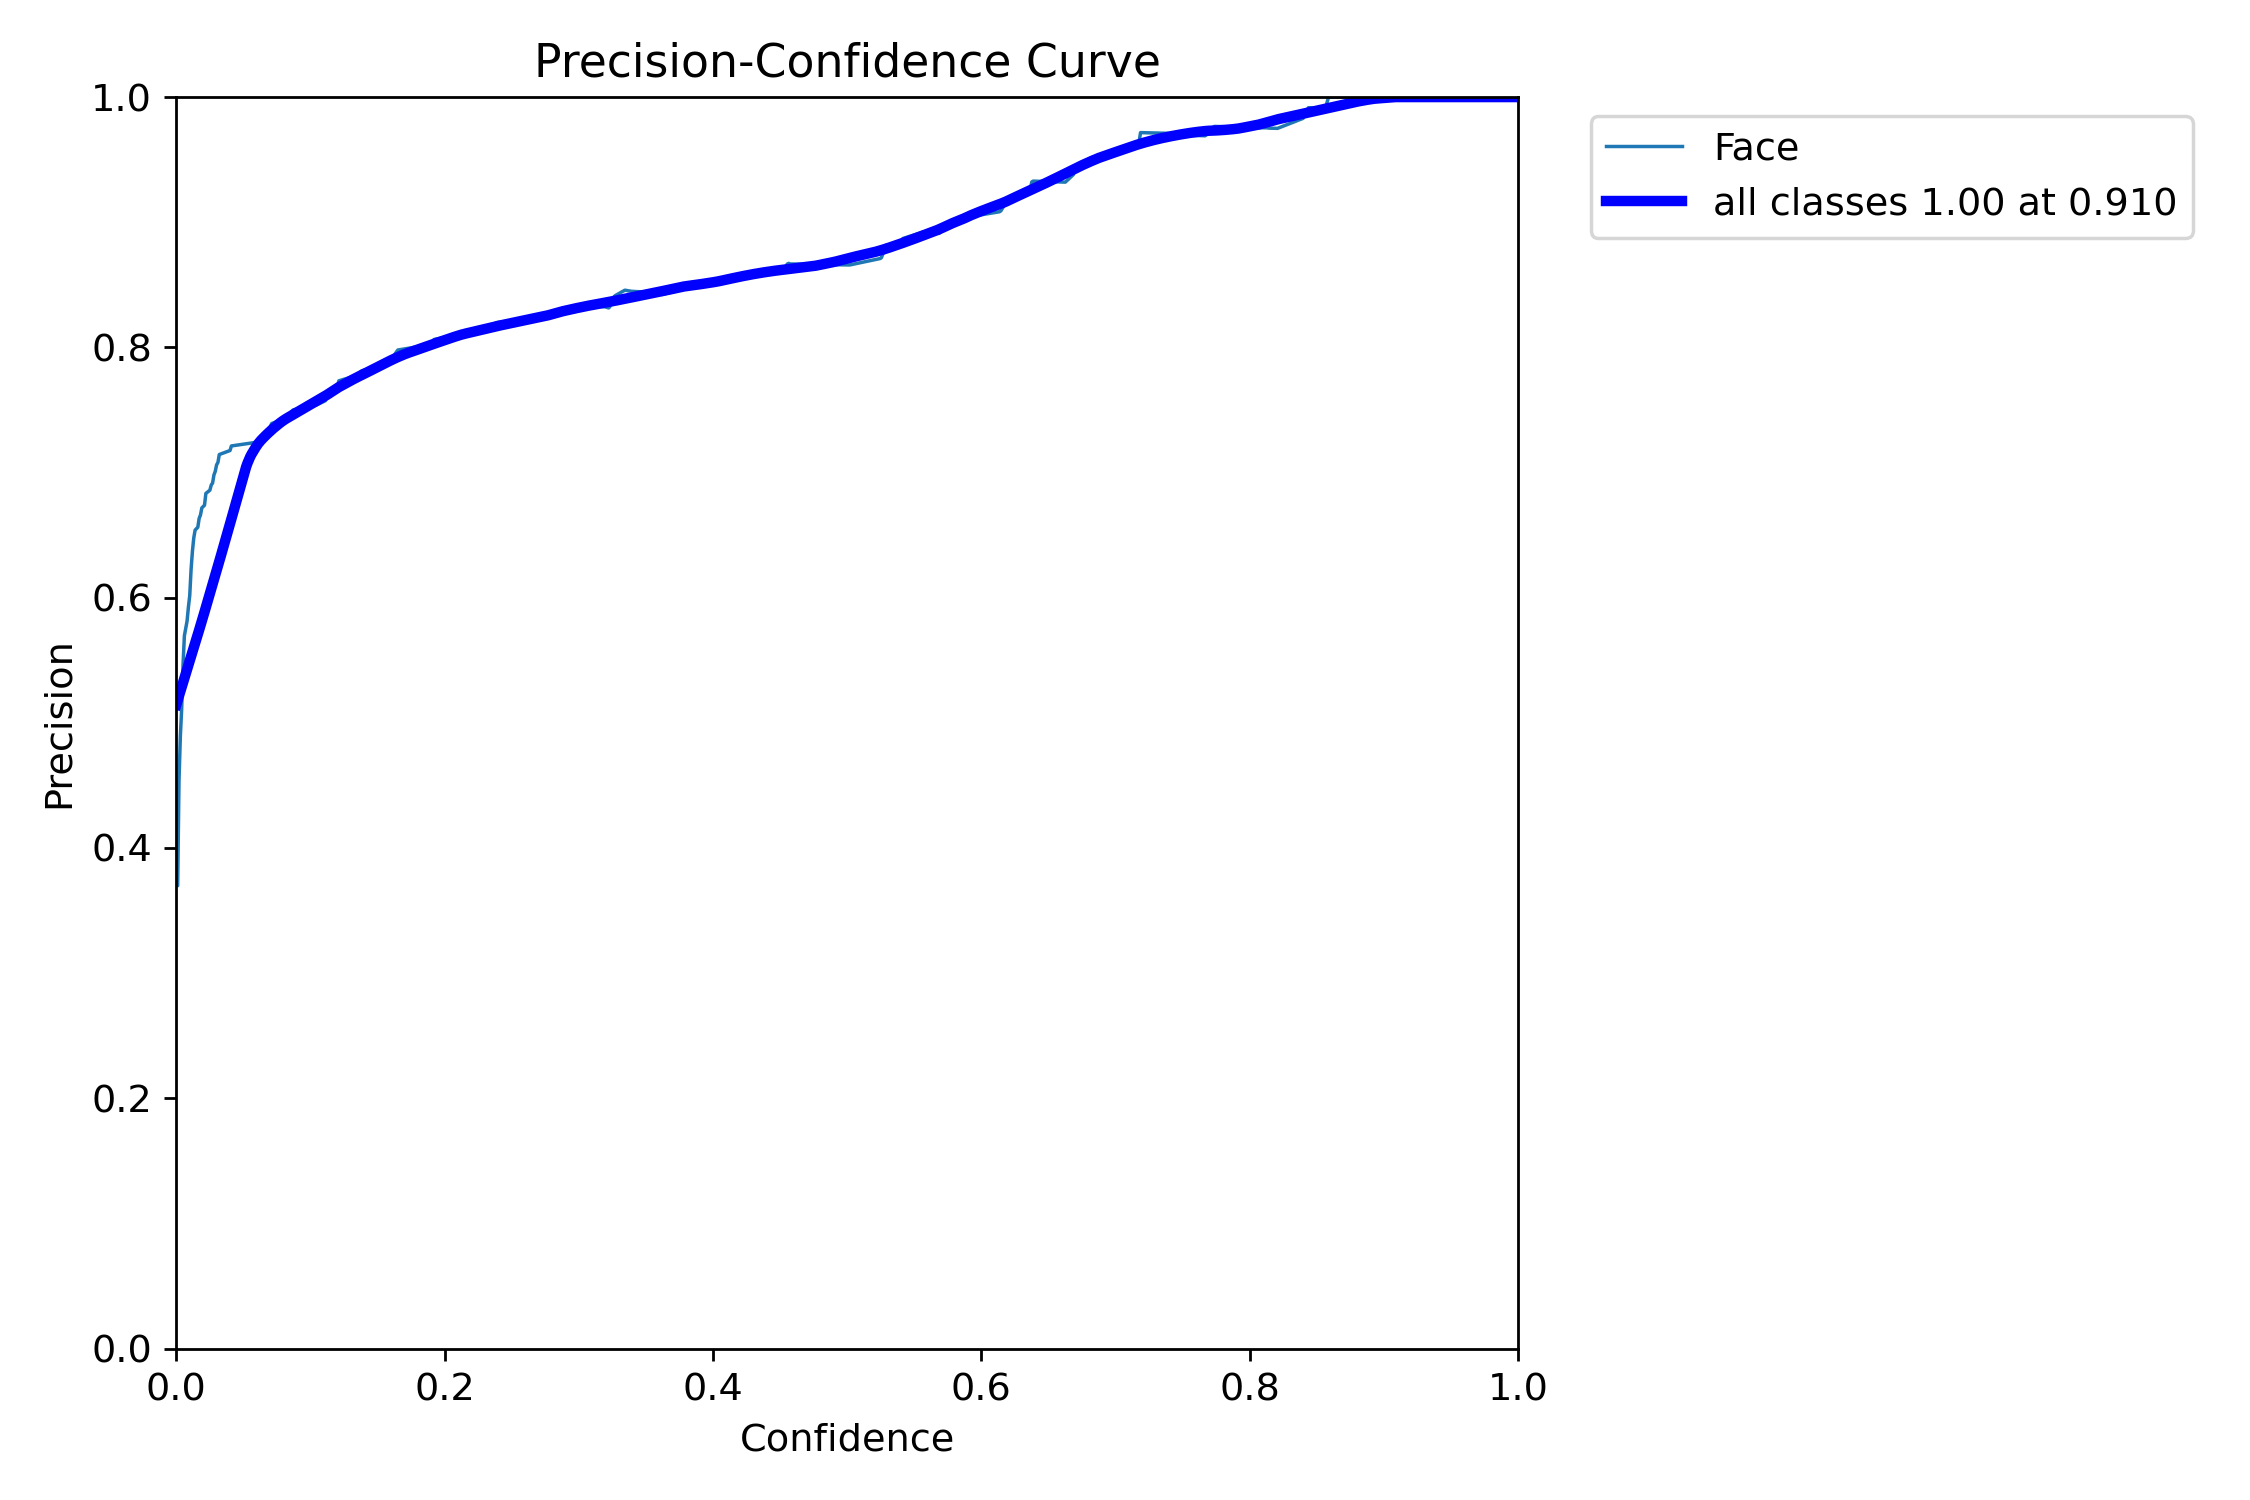

In [46]:
Image(filename=f"{resultData}BoxP_curve.png")

RUNNING PREDICTION WITH BEST MODEL

In [17]:
bestModel = YOLO(f'{resultData}weights/best.pt')
bestModel.predict(source="Face-Detection-1/test/images", save=True)



image 1/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0218_png.rf.dd2e8c8b2989f6690e64a7a72cc566a1.jpg: 640x640 1 Face, 33.8ms
image 2/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0223_png_jpg.rf.171c687ced62d1671fd7d48cdb3082c3.jpg: 640x640 1 Face, 32.4ms
image 3/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0231_png.rf.d1f505d848a6d9198170bf7083960102.jpg: 640x640 1 Face, 32.5ms
image 4/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0235_png.rf.8ac5b327a03ef6906ecf593231ec0711.jpg: 640x640 1 Face, 30.5ms
image 5/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0259_png_jpg.rf.2557556d0b09917520e60b9c74b43663.jpg: 640x640 1 Face, 30.1ms
image 6/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\image

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Face'}
 obb: None
 orig_img: array([[[ 60,  75,  94],
         [ 60,  75,  94],
         [ 60,  75,  94],
         ...,
         [ 58,  67,  76],
         [ 58,  67,  76],
         [ 59,  68,  77]],
 
        [[ 59,  74,  93],
         [ 59,  74,  93],
         [ 59,  74,  93],
         ...,
         [ 58,  67,  76],
         [ 58,  67,  76],
         [ 59,  68,  77]],
 
        [[ 58,  73,  92],
         [ 58,  73,  92],
         [ 58,  73,  92],
         ...,
         [ 58,  67,  76],
         [ 58,  67,  76],
         [ 59,  68,  77]],
 
        ...,
 
        [[ 81, 121, 169],
         [ 81, 121, 169],
         [ 80, 120, 168],
         ...,
         [  2,   2,   2],
         [  2,   2,   2],
         [  2,   2,   2]],
 
        [[ 82, 122, 170],
         [ 81, 121, 169],
         [ 81, 121, 169],
         ...,
         [  2,   2, 

<h3>Dislaying Predicted Images with face detection</h3>

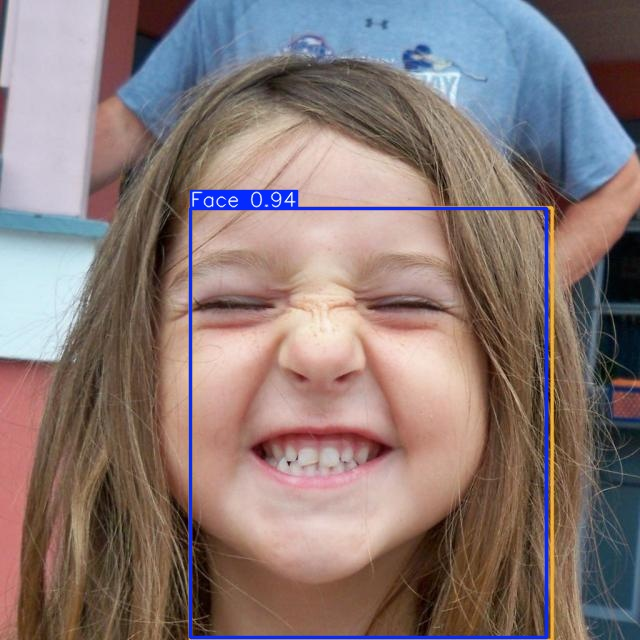

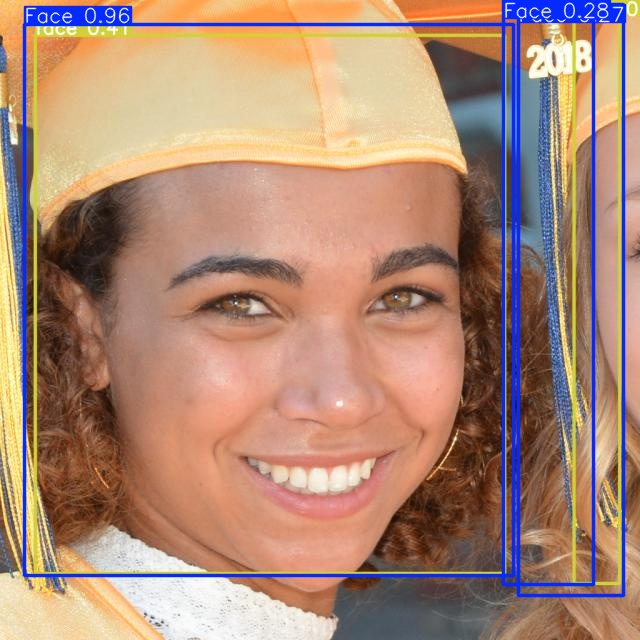

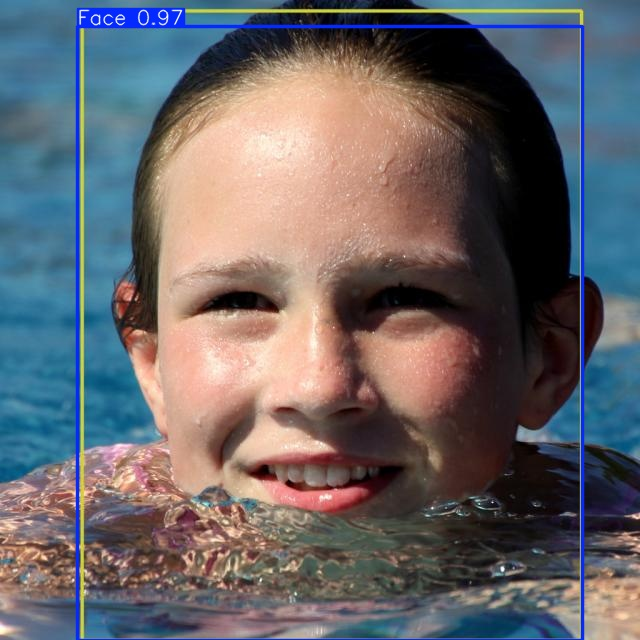

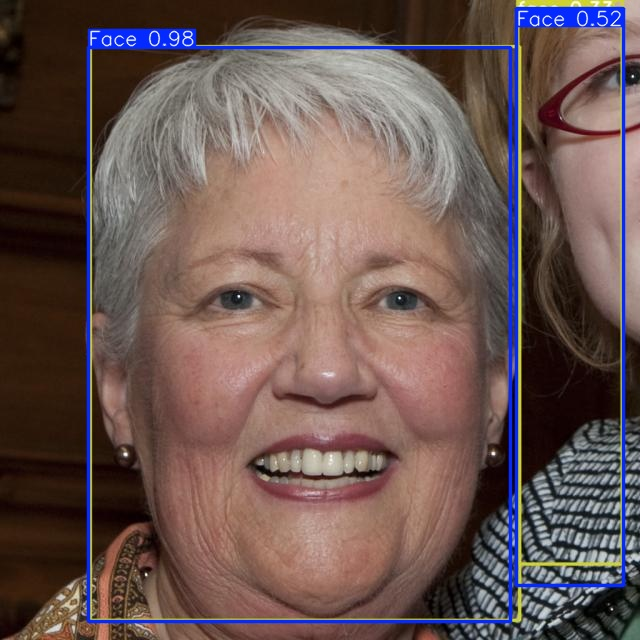

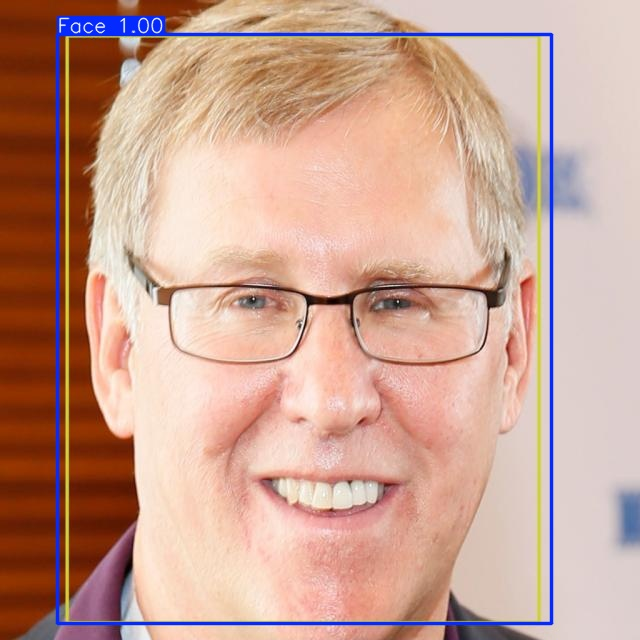

In [81]:
import glob


predicted_img_list_v8 = list(glob.glob("runs/detect/predict2/*.jpg"))

for image in predicted_img_list_v8[-5:]:
    display(Image(filename=image))


In [7]:
!pip install opencv-python

  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.1.0 requires dill<0.3.9,>=0.3.0, which is not installed.
flwr-datasets 0.5.0 requires seaborn<0.14.0,>=0.13.0, which is not installed.
scikit-learn 1.6.1 requires joblib>=1.2.0, which is not installed.
datasets 3.1.0 requires fsspec[http]<=2024.9.0,>=2023.1.0, but you have fsspec 2025.10.0 which is incompatible.
roboflow 1.2.11 requires idna==3.7, but you have idna 3.11 which is incompatible.


In [43]:
import cv2

def detect_face_webcam (test_model):
    
    # Open the default webcam (index 0)
    # Use 1, 2, etc. if you have multiple cameras
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Cannot open webcam")
        exit()

    print("Webcam opened successfully. Press 'Esc' to exit.")

    while True:
        # Read a frame from the webcam
        success, frame = cap.read()

        if not success:
            break

        # Run YOLOv8 inference on the frame
        # The 'stream=True' argument makes it an iterator for efficiency in video processing
        results = test_model(frame, stream=True)

        # Process results and draw bounding boxes on the frame
        for r in results:
            # Get the bounding box coordinates, confidence, and class
            boxes = r.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                confidence = round(float(box.conf[0]), 2)
                class_idx = int(box.cls[0])
                class_name = model.names[class_idx]
                label = f'{class_name} {confidence}'

                # Draw the bounding box and label
                color = (0, 255, 0) # Green BGR
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Display the resulting frame
        cv2.imshow('YOLO Webcam Object Detection', frame)

        # Break the loop if 'Esc' key is pressed
        if cv2.waitKey(1) == 27: # 27 is the ASCII for the Esc key
            break

    # Release the webcam and destroy all windows
    cap.release()
    cv2.destroyAllWindows()


In [32]:
model2 = YOLO("yolo11n.pt")
training_result2 = model2.train(data="Face-Detection-1/data.yaml", epochs=80, batch = 4)

New https://pypi.org/project/ultralytics/8.3.234 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.233  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Face-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train22, nbs=64, nms=False,

<h3>Dislaing Trained Images for Yolo11</h3>

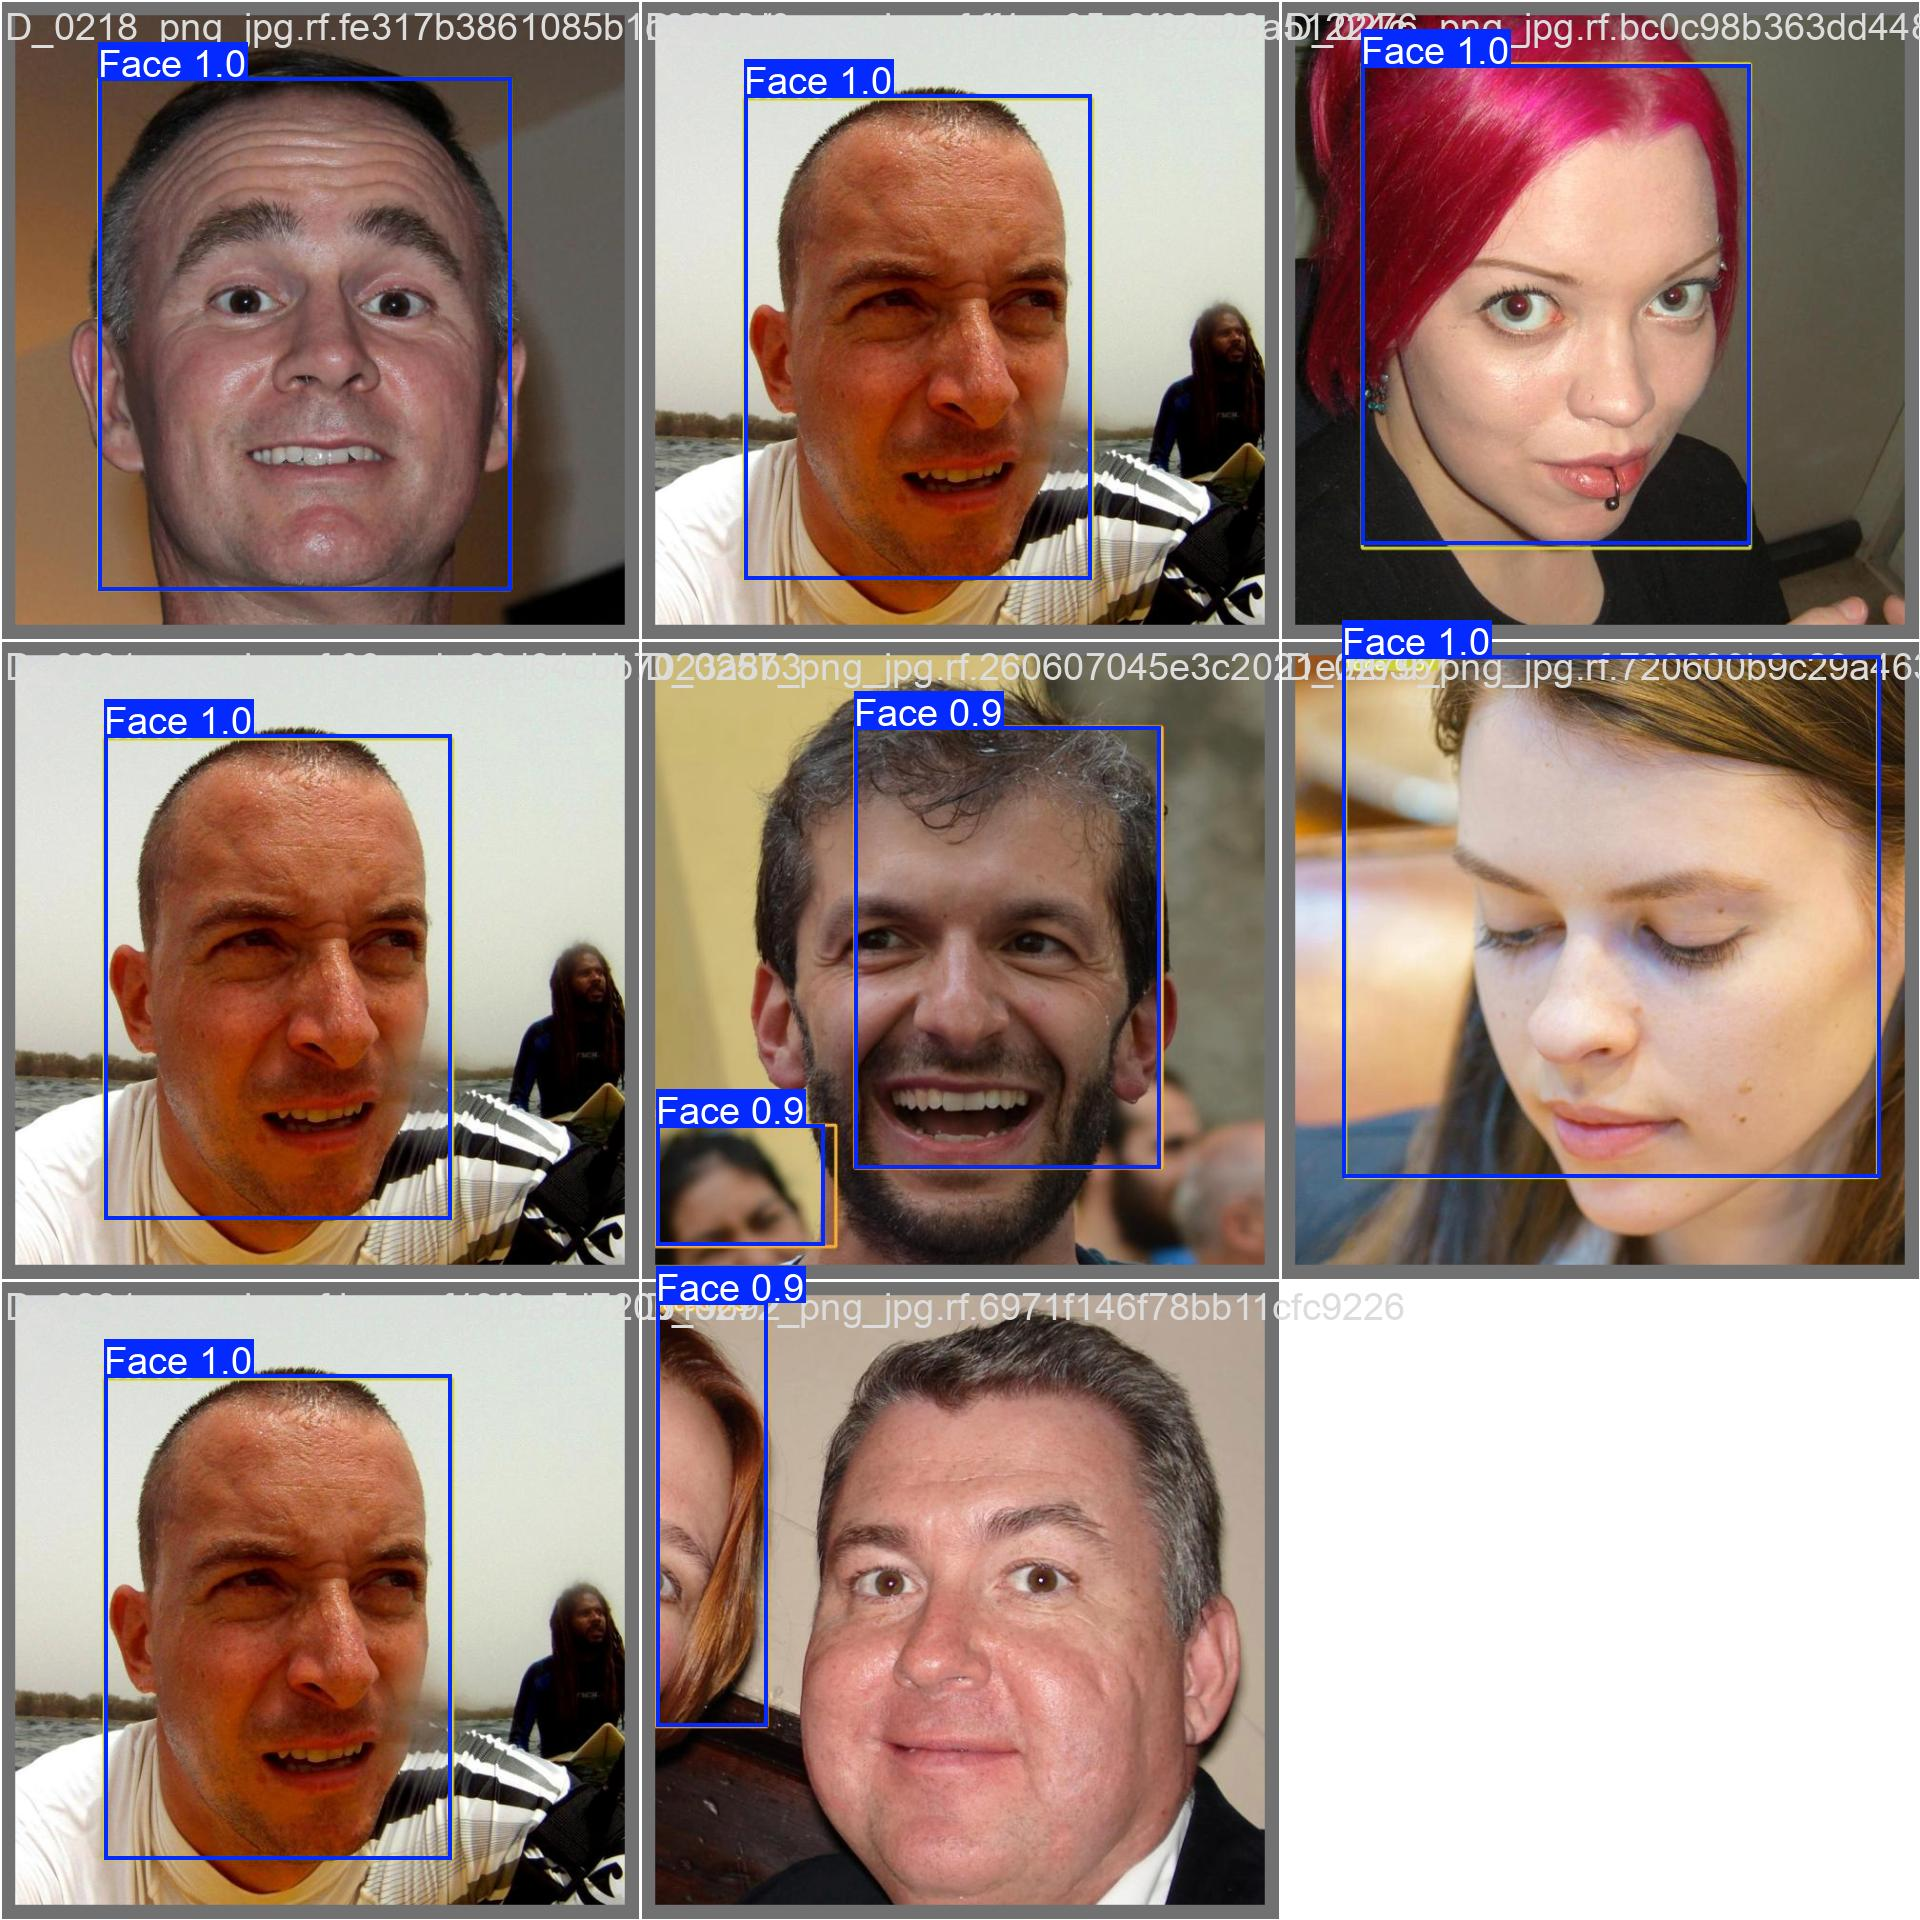

In [84]:
Image(filename=f"{resultData_11}val_batch2_pred.jpg")

In [33]:
result_2 = model2.val(data = "Face-Detection-1/data.yaml")

Ultralytics 8.3.233  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1050, 4096MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 3.10.6 MB/s, size: 48.3 KB)
val: Scanning C:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\valid\labels.cache... 97 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 97/97 53.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.9s/it 13.6s1.6s
                   all         97        155      0.918      0.942      0.968      0.859
Speed: 3.3ms preprocess, 13.7ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to C:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\runs\detect\val7


In [34]:

print("Precision:", result_2.box.ap[0])
print("Recall: ", result_2.box.r[0])
print("F1 score:", result_2.box.f1)


Precision: 0.8589106418280474
Recall:  0.9417231948086175
F1 score: [    0.92982]


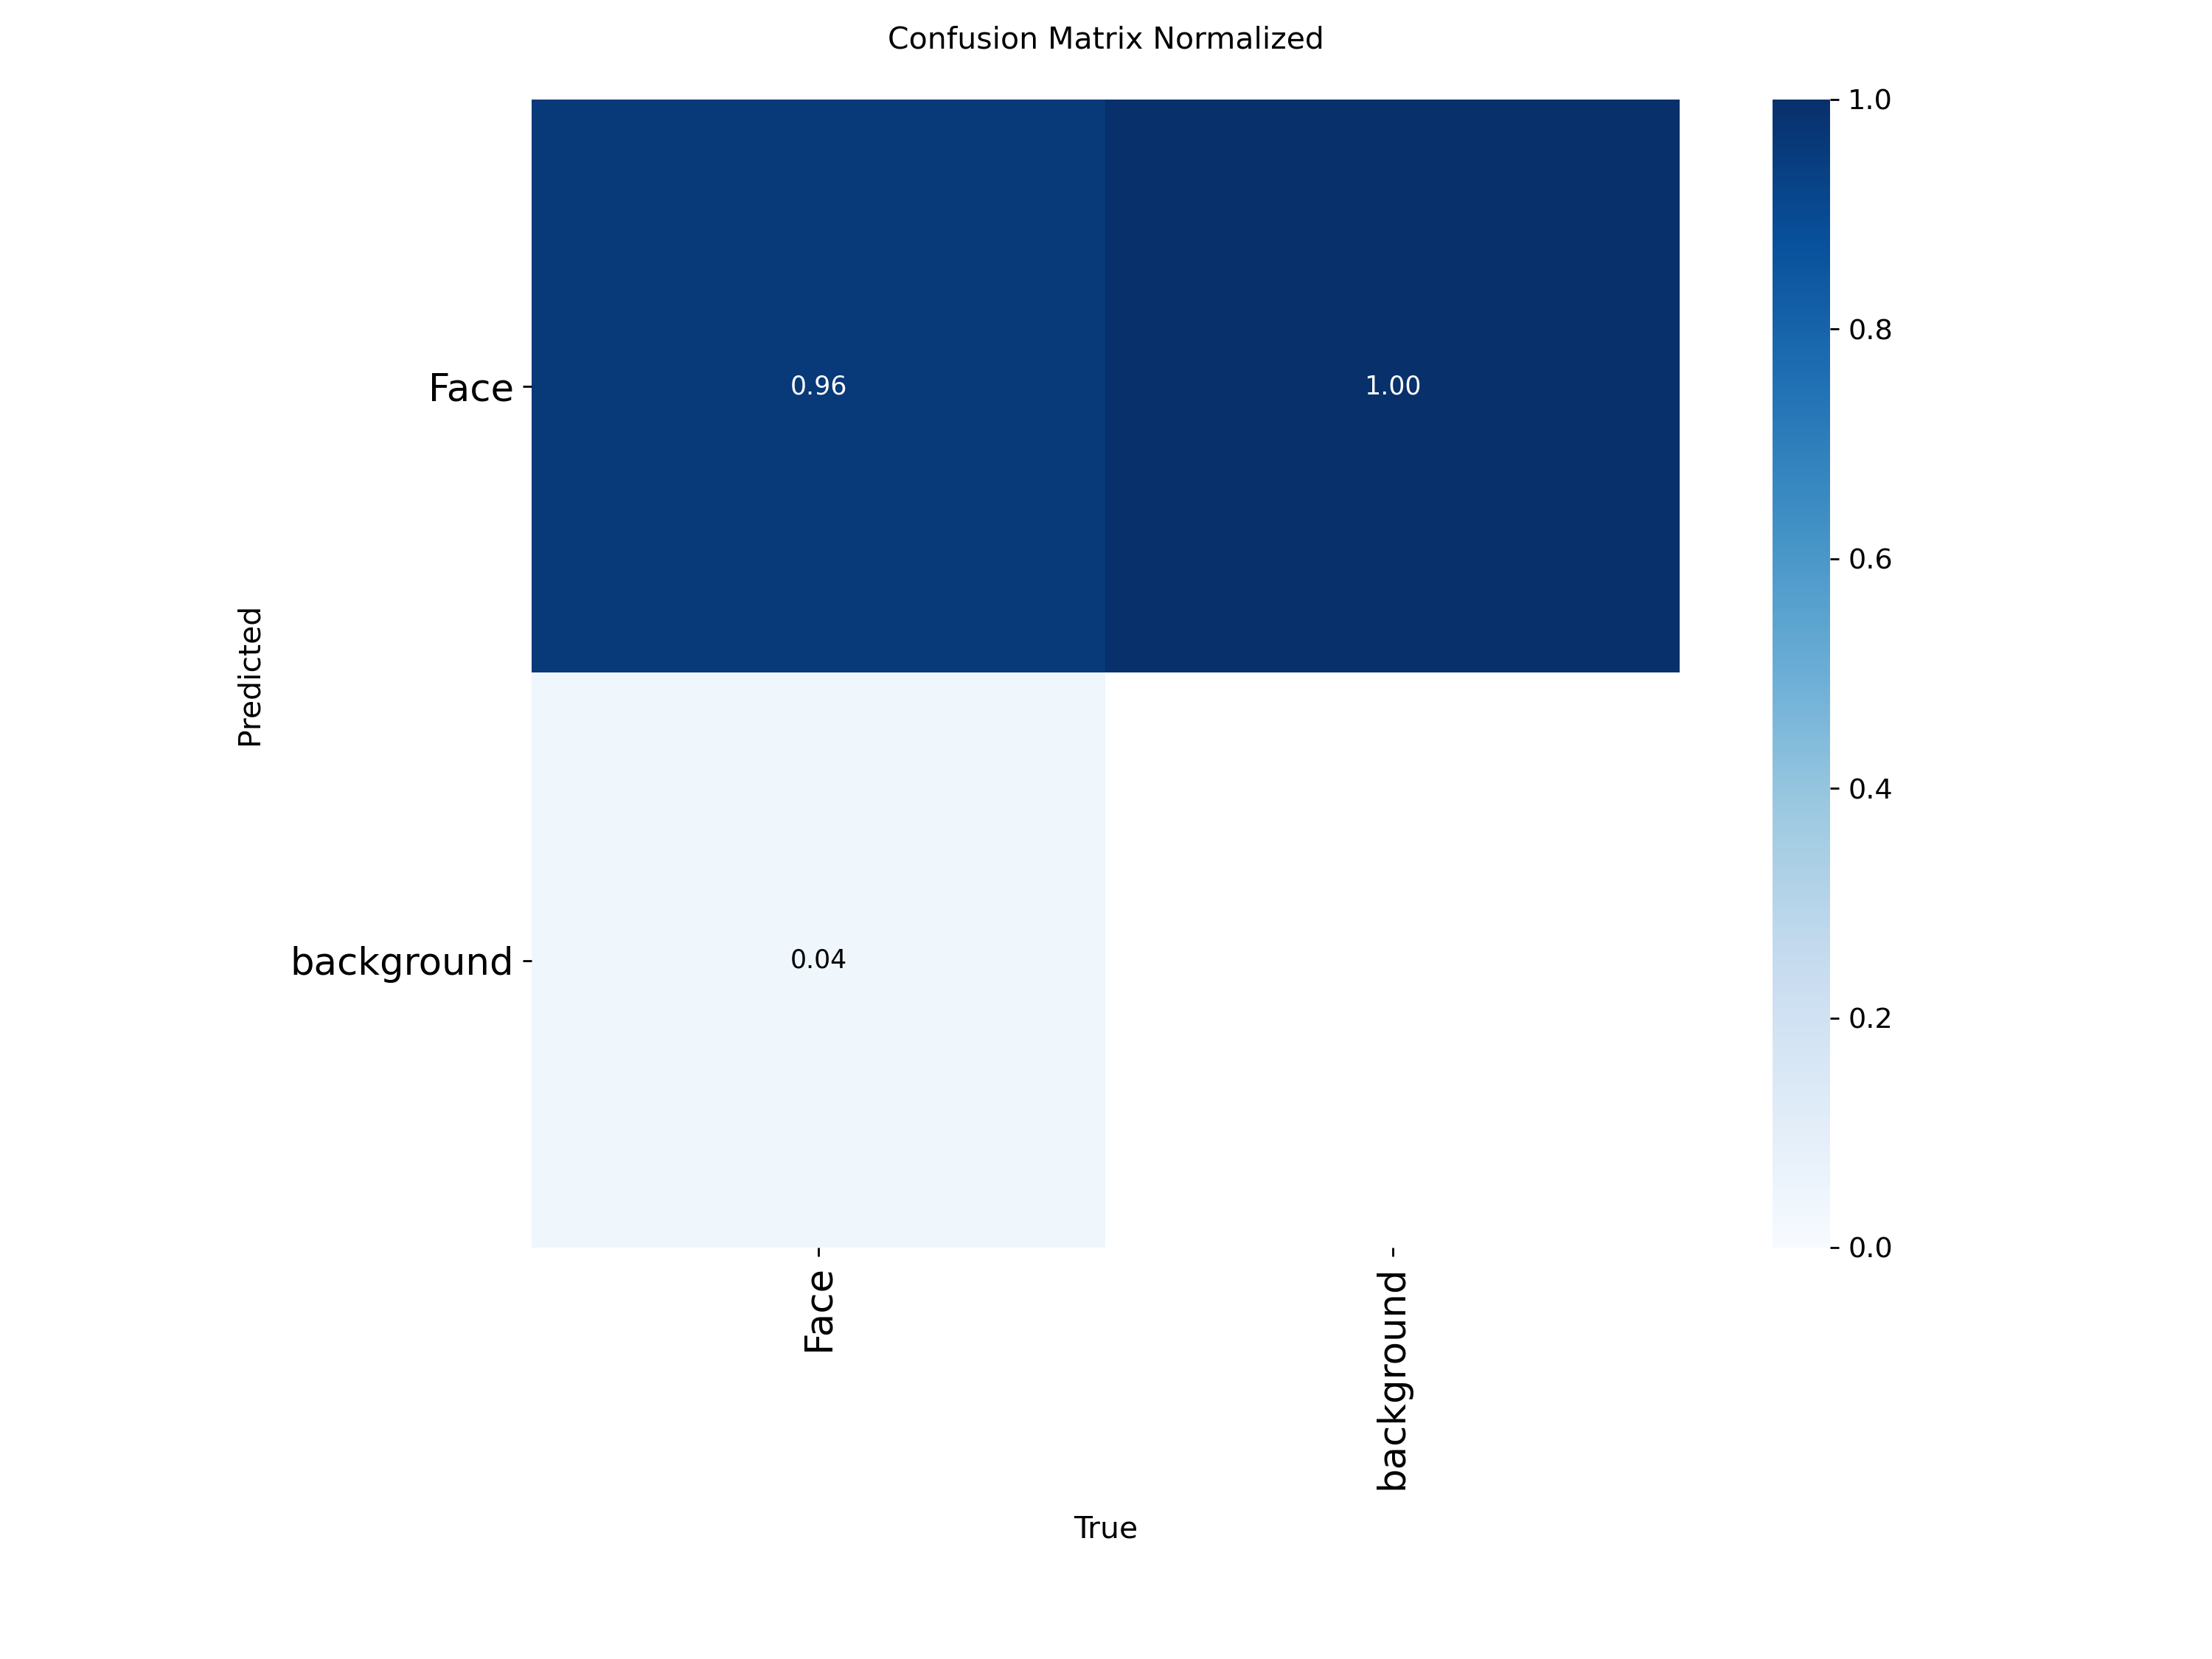

In [85]:
Image(filename=f"{resultData_11}confusion_matrix_normalized.png")

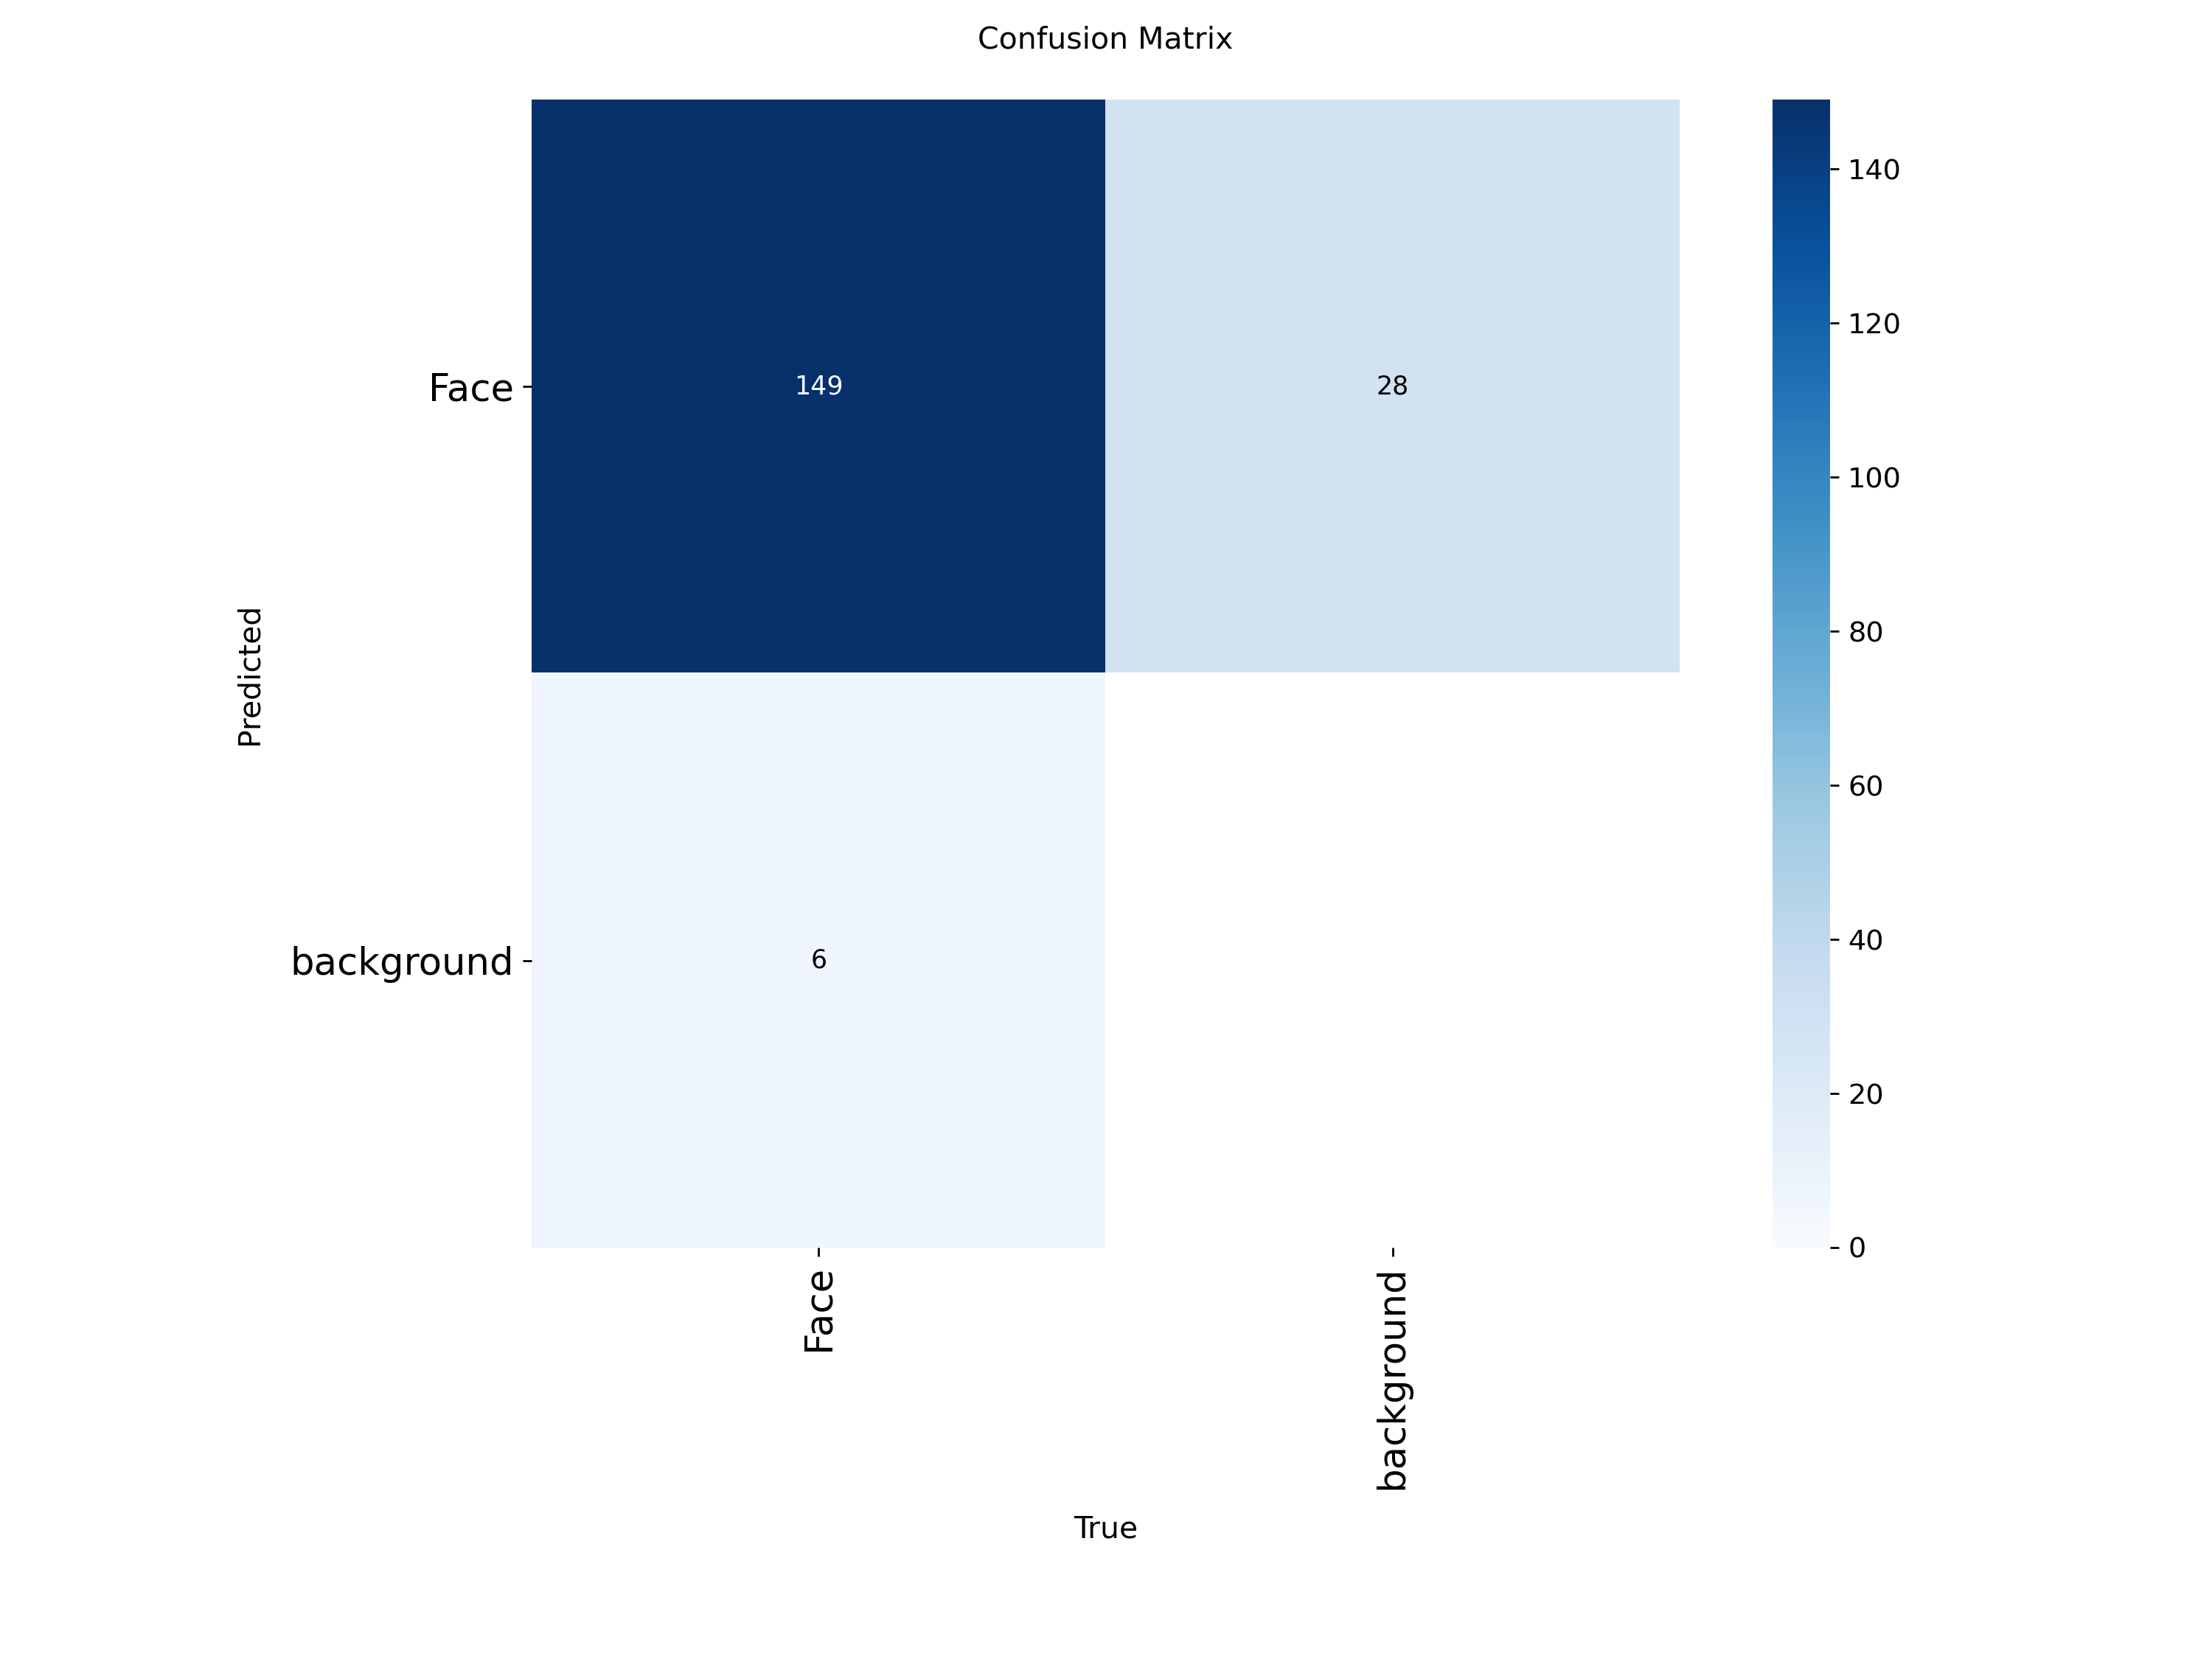

In [86]:
Image(filename=f"{resultData_11}confusion_matrix.png")

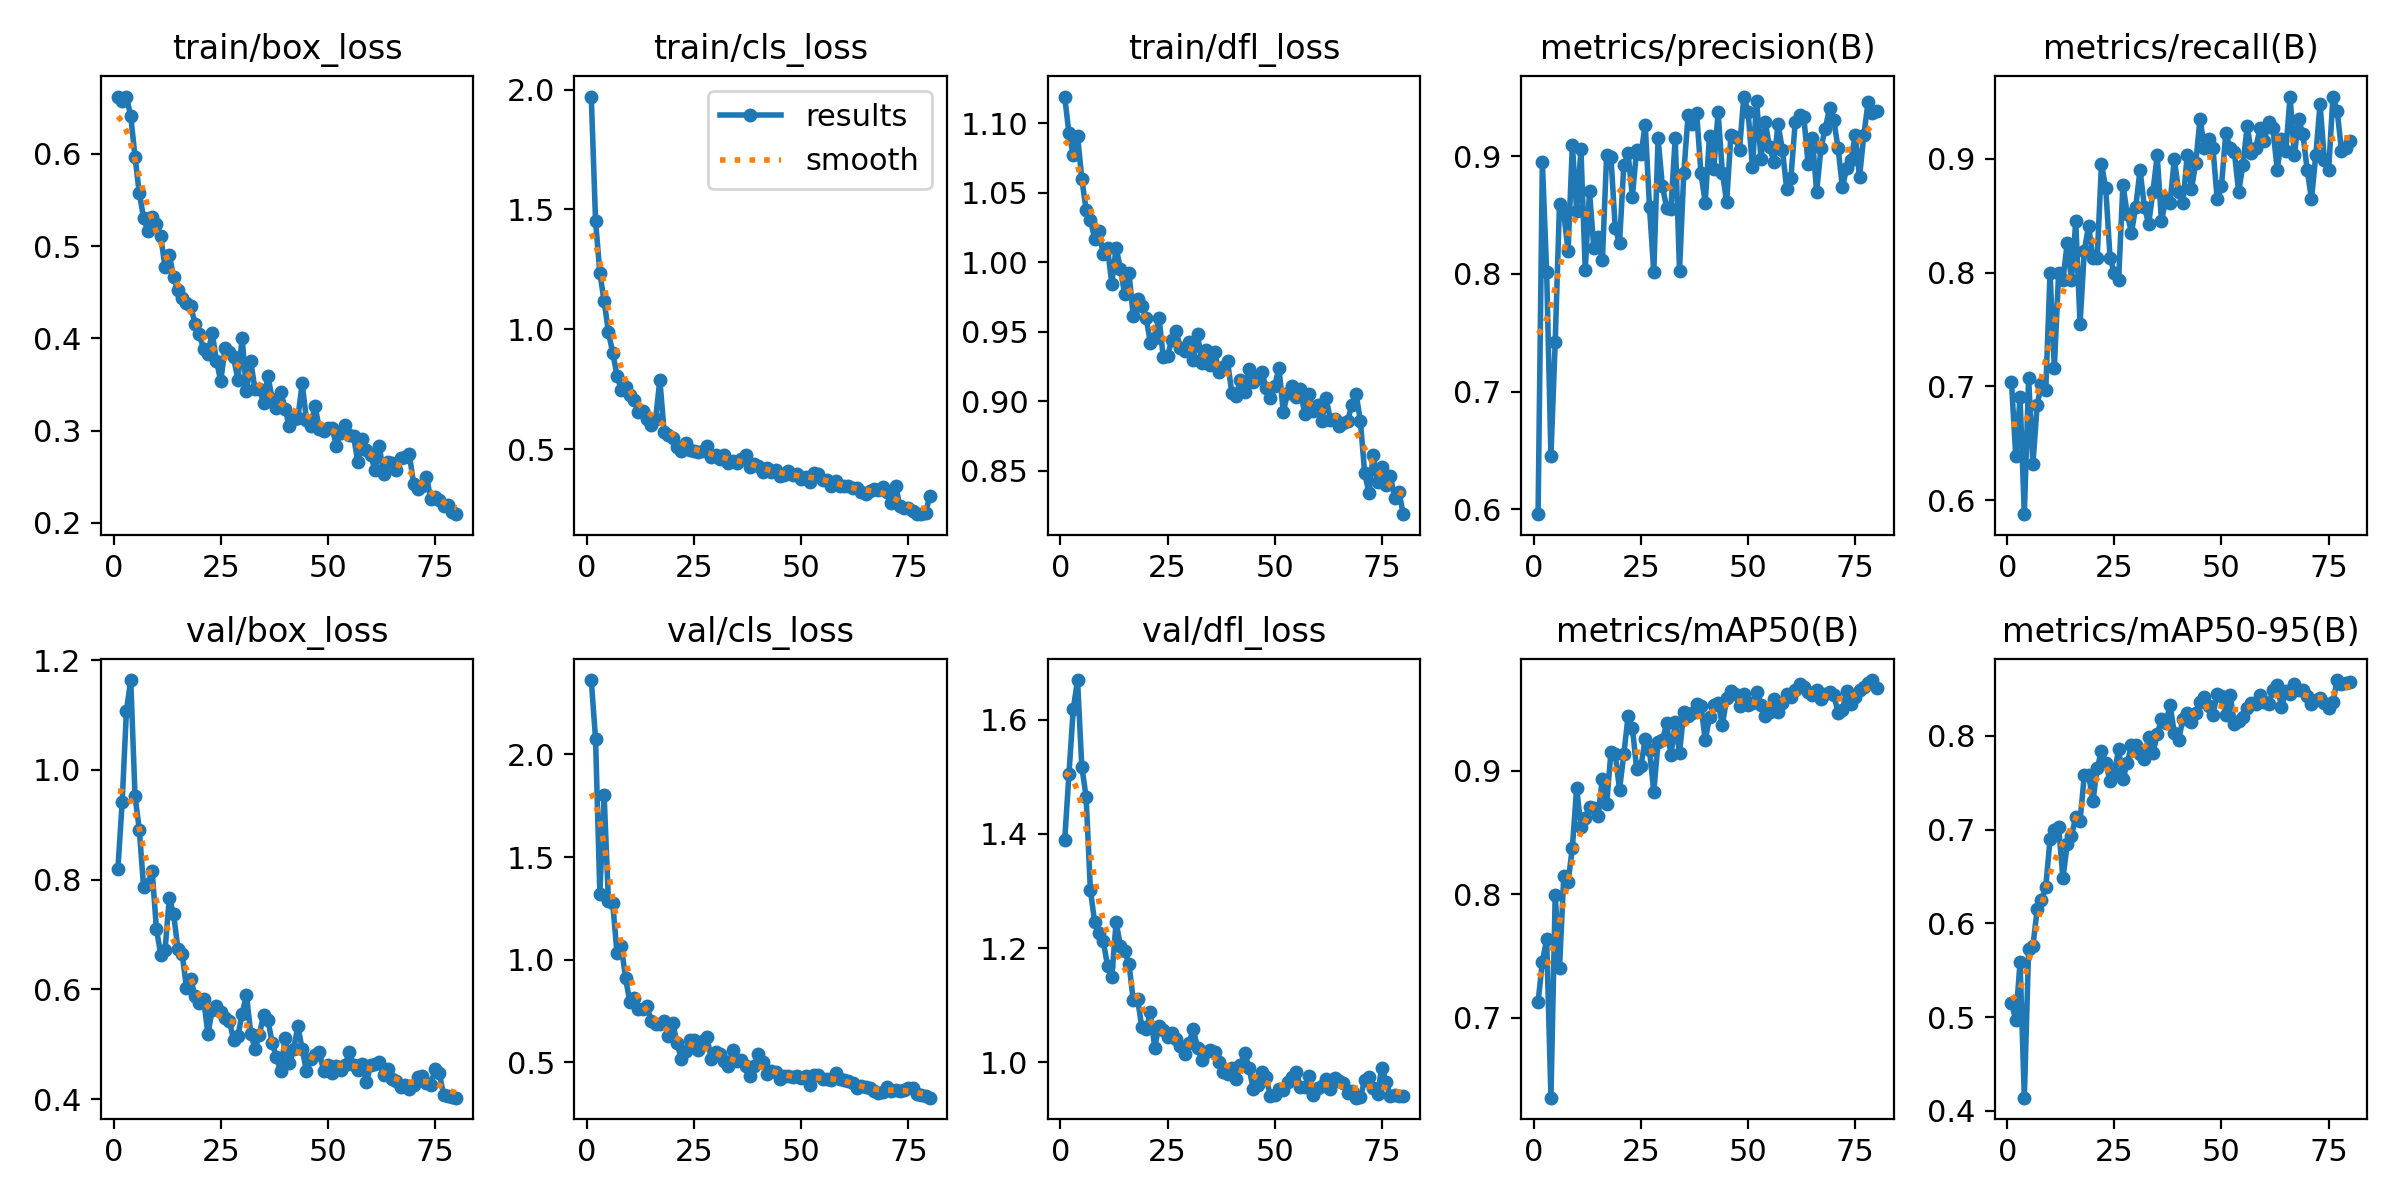

In [88]:
Image(filename=f"{resultData_11}results.png")

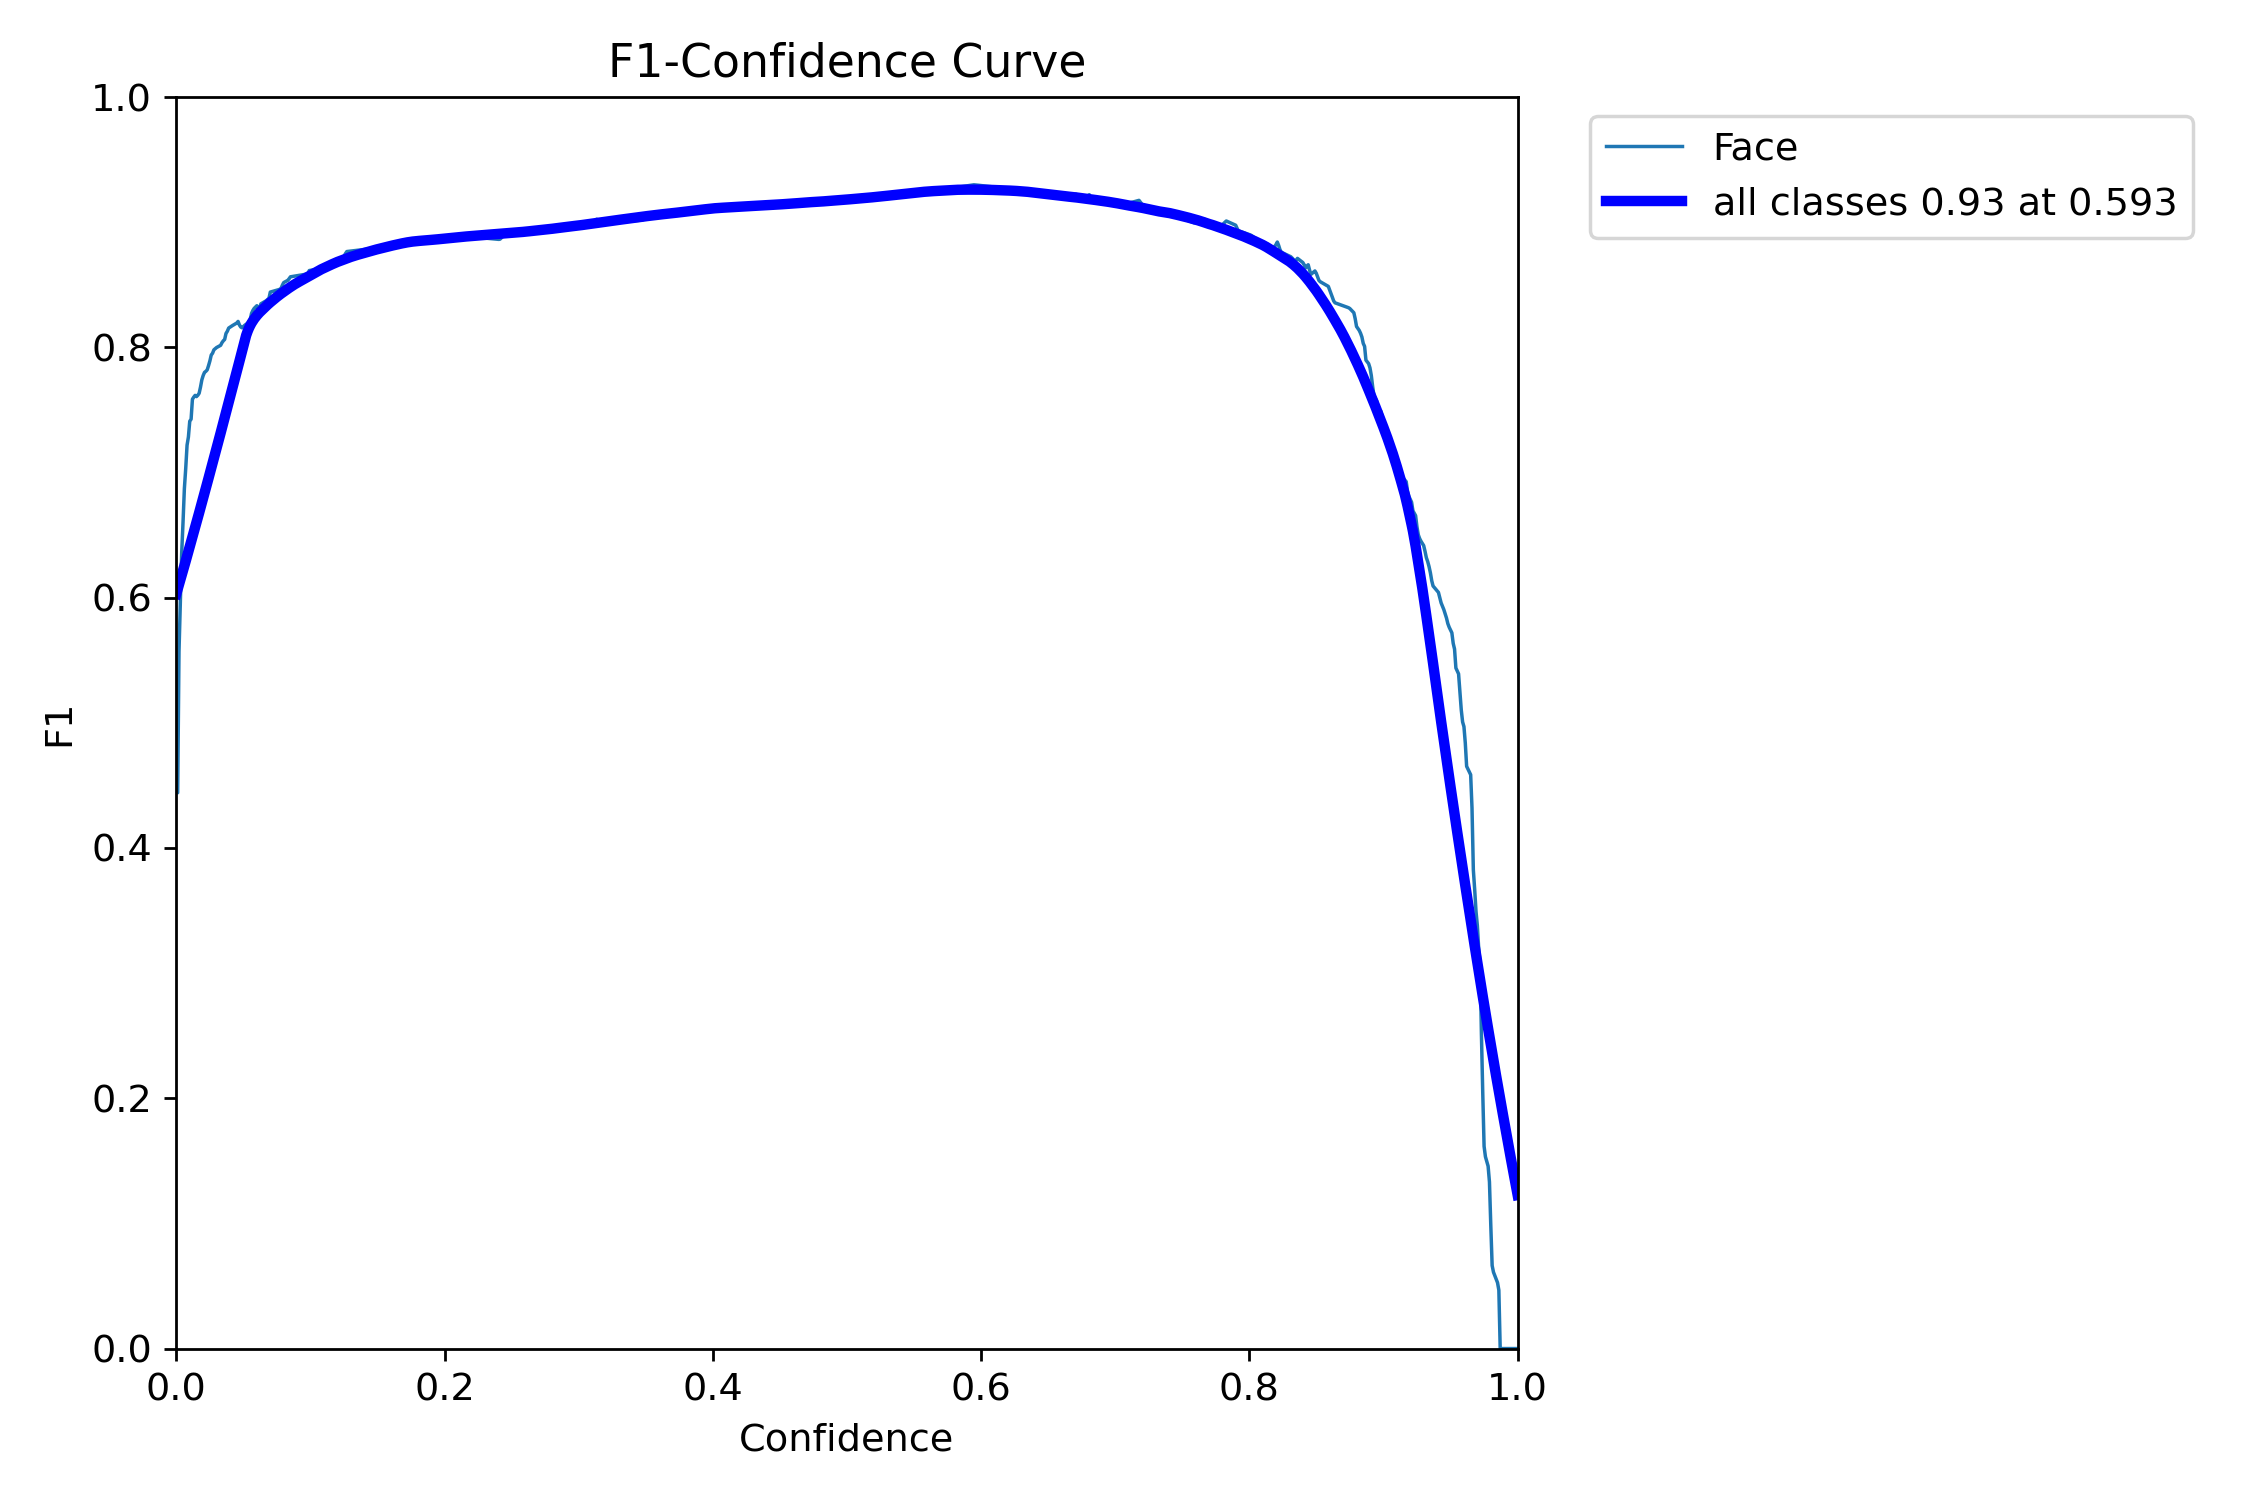

In [92]:
Image(filename=f"{resultData_11}BoxF1_curve.png")

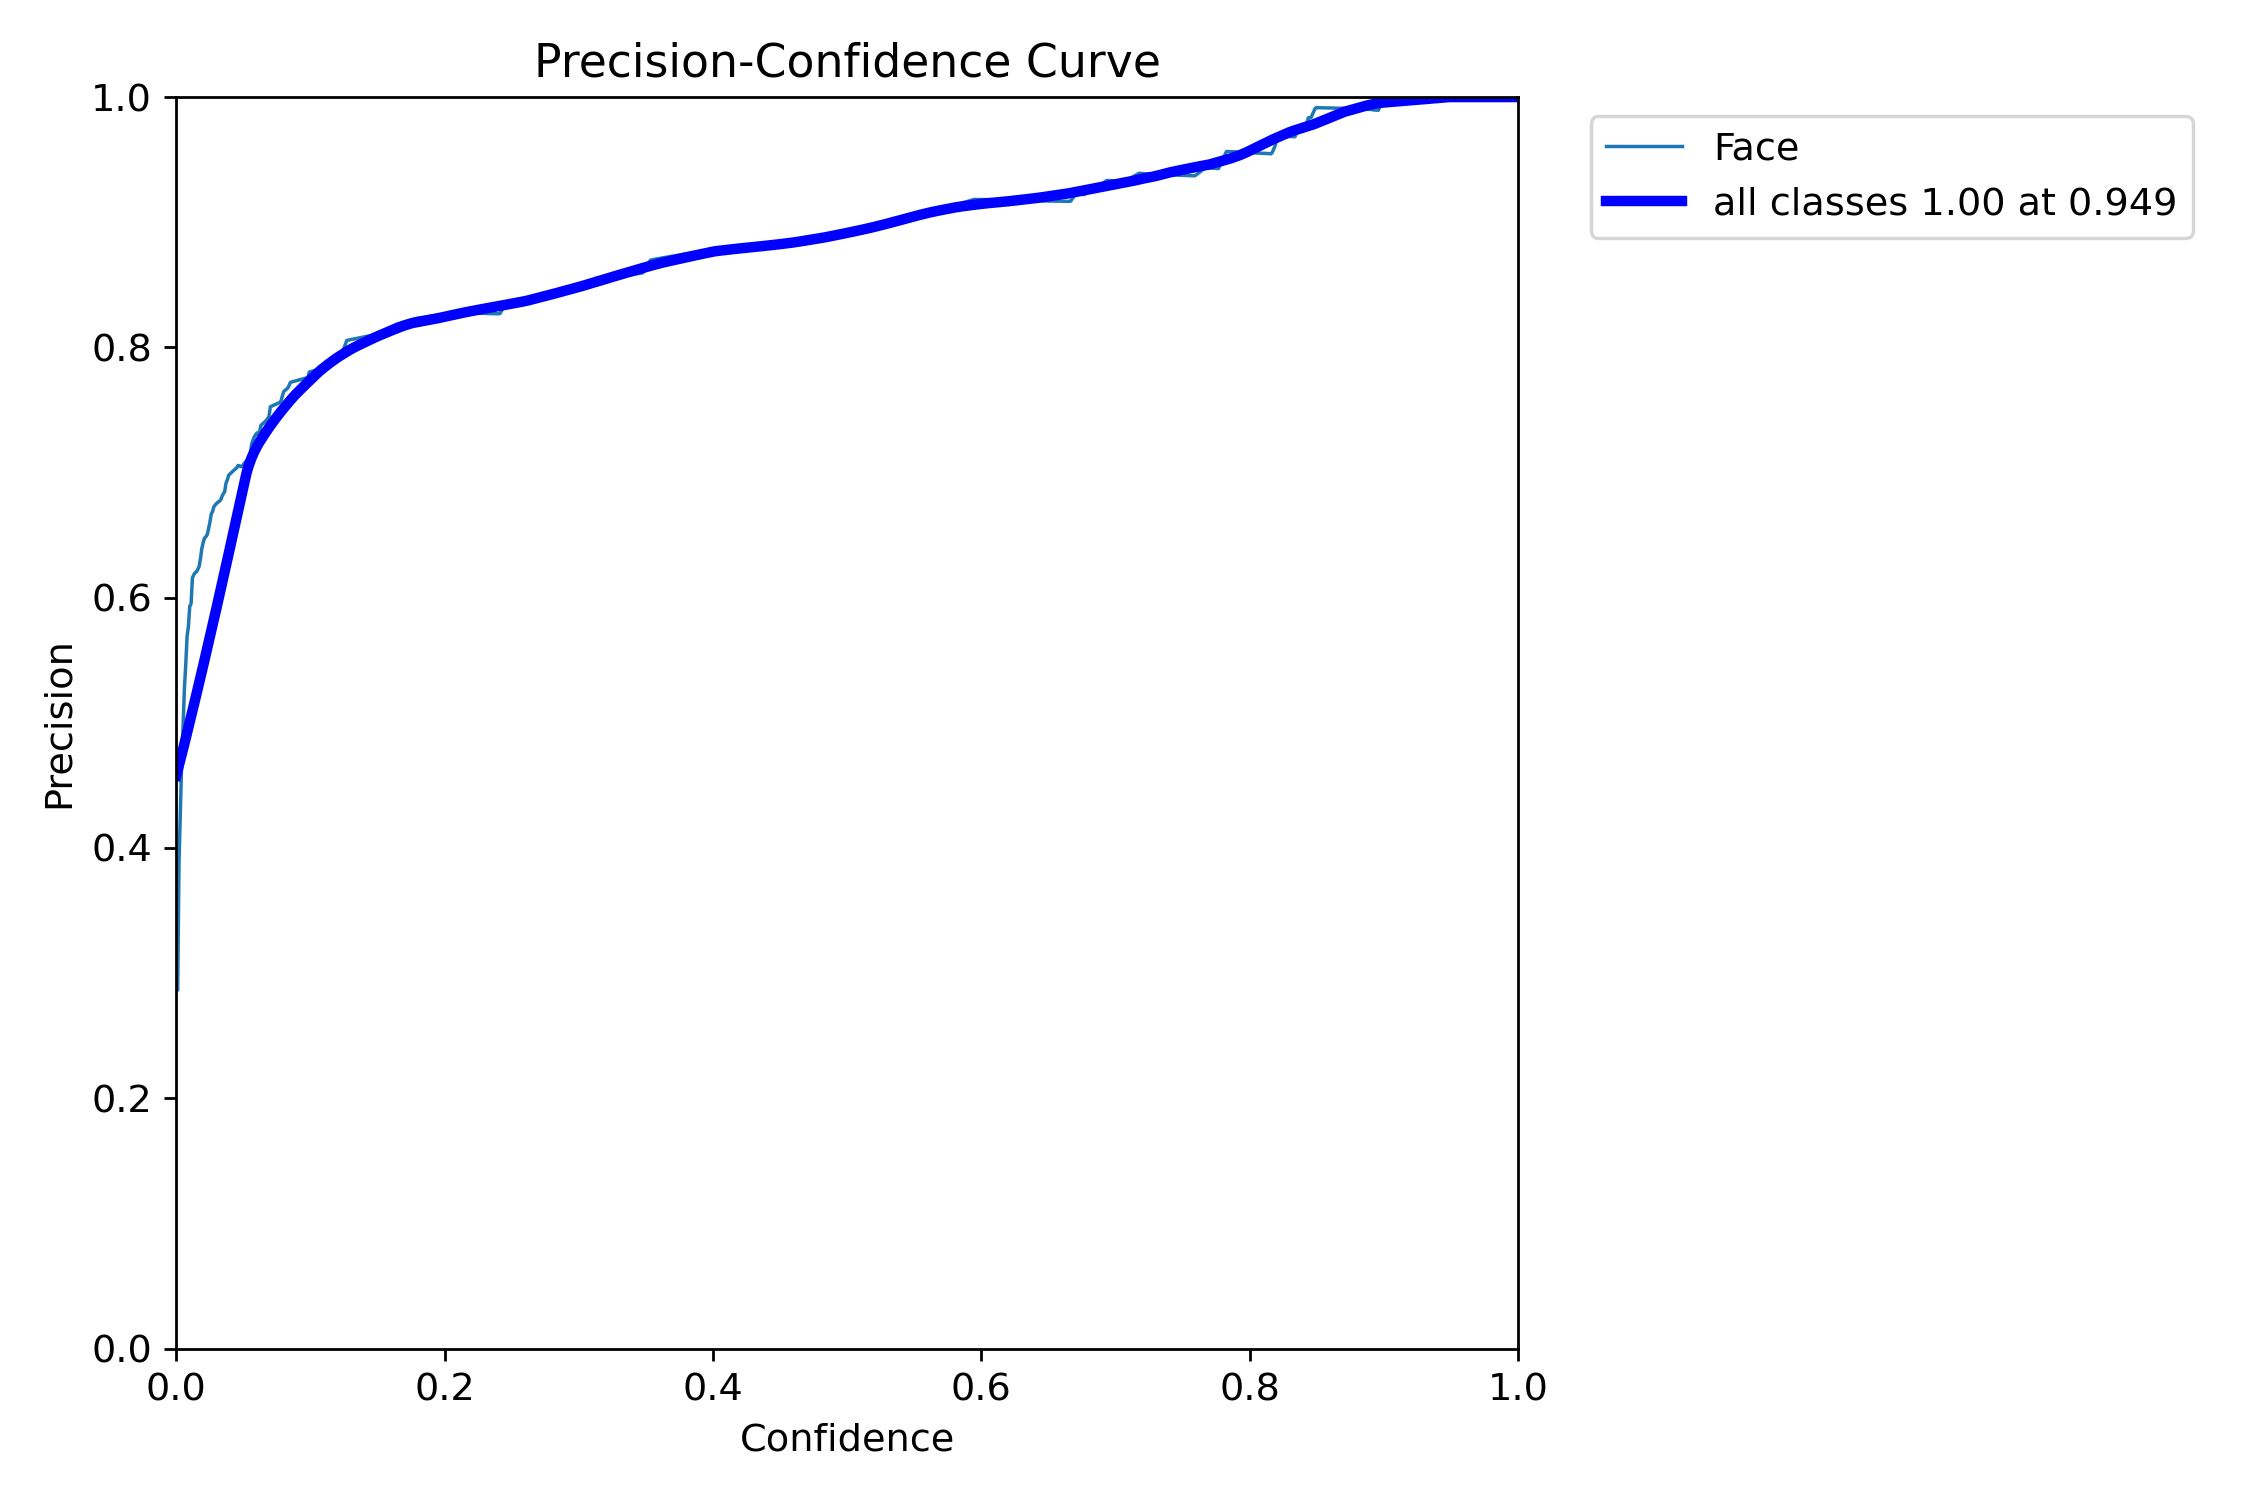

In [93]:
Image(filename=f"{resultData_11}BoxP_curve.png")

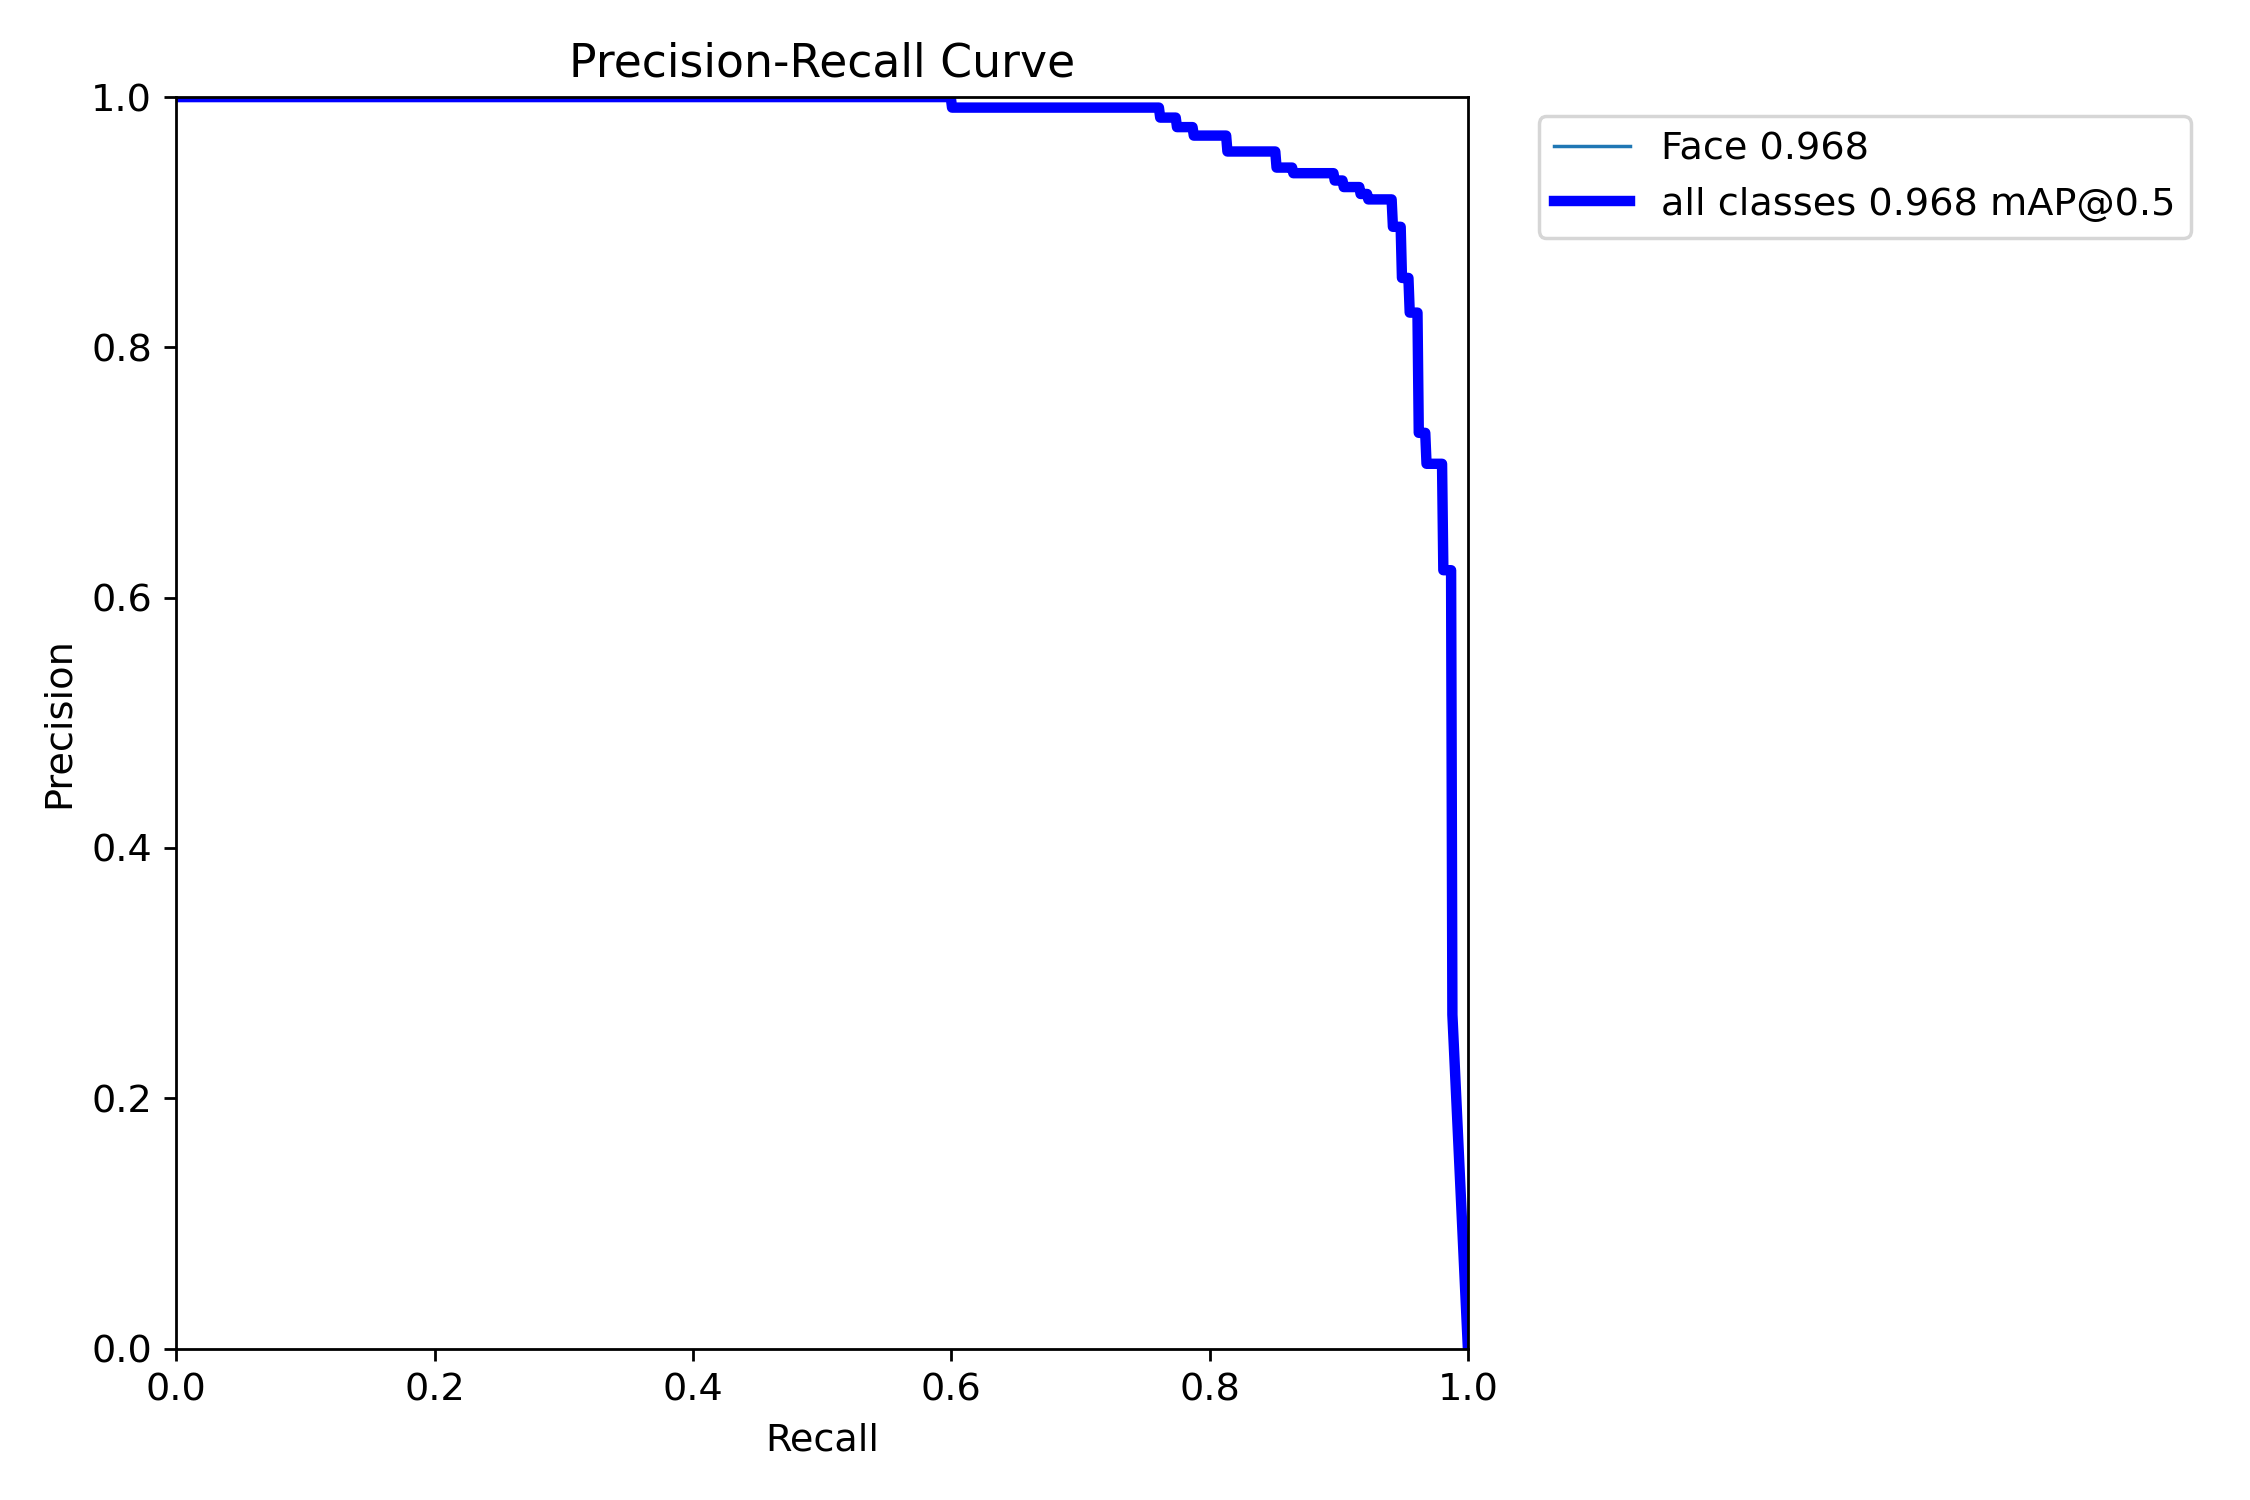

In [94]:
Image(filename=f"{resultData_11}BoxPR_curve.png")

In [35]:
bestModel_11 = YOLO(f'{resultData}weights/best.pt')
bestModel_11.predict(source="Face-Detection-1/test/images", save=True)



image 1/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0218_png.rf.dd2e8c8b2989f6690e64a7a72cc566a1.jpg: 640x640 1 Face, 32.6ms
image 2/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0223_png_jpg.rf.171c687ced62d1671fd7d48cdb3082c3.jpg: 640x640 1 Face, 32.9ms
image 3/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0231_png.rf.d1f505d848a6d9198170bf7083960102.jpg: 640x640 1 Face, 33.9ms
image 4/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0235_png.rf.8ac5b327a03ef6906ecf593231ec0711.jpg: 640x640 1 Face, 33.3ms
image 5/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\images\D_0259_png_jpg.rf.2557556d0b09917520e60b9c74b43663.jpg: 640x640 1 Face, 32.9ms
image 6/110 c:\Users\Sumit\OneDrive\Documents\DeepLearning\Face Detection\Face-Detection-1\test\image

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Face'}
 obb: None
 orig_img: array([[[ 60,  75,  94],
         [ 60,  75,  94],
         [ 60,  75,  94],
         ...,
         [ 58,  67,  76],
         [ 58,  67,  76],
         [ 59,  68,  77]],
 
        [[ 59,  74,  93],
         [ 59,  74,  93],
         [ 59,  74,  93],
         ...,
         [ 58,  67,  76],
         [ 58,  67,  76],
         [ 59,  68,  77]],
 
        [[ 58,  73,  92],
         [ 58,  73,  92],
         [ 58,  73,  92],
         ...,
         [ 58,  67,  76],
         [ 58,  67,  76],
         [ 59,  68,  77]],
 
        ...,
 
        [[ 81, 121, 169],
         [ 81, 121, 169],
         [ 80, 120, 168],
         ...,
         [  2,   2,   2],
         [  2,   2,   2],
         [  2,   2,   2]],
 
        [[ 82, 122, 170],
         [ 81, 121, 169],
         [ 81, 121, 169],
         ...,
         [  2,   2, 

<h3>Displaying Predicted Images</h3>

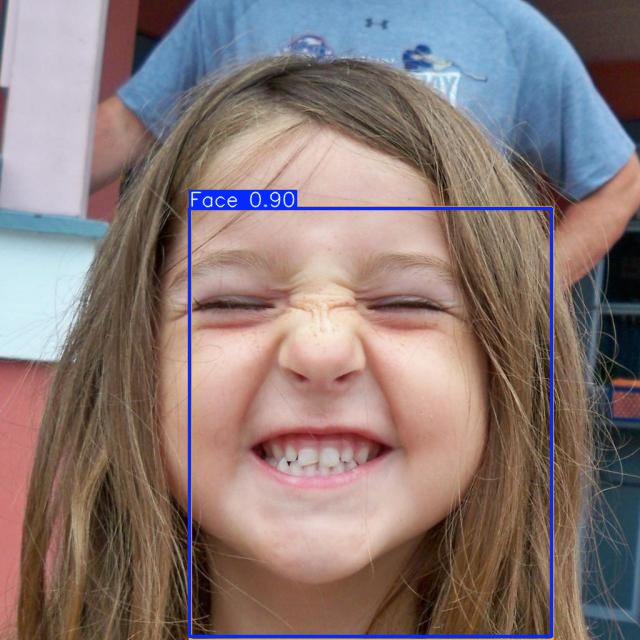

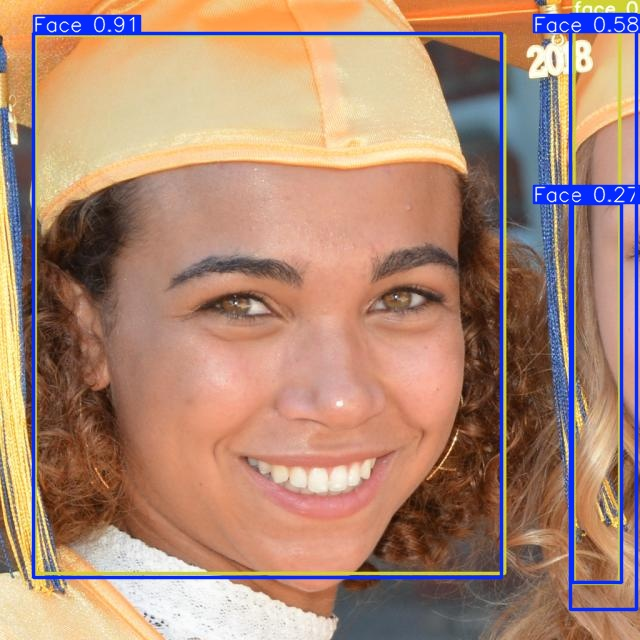

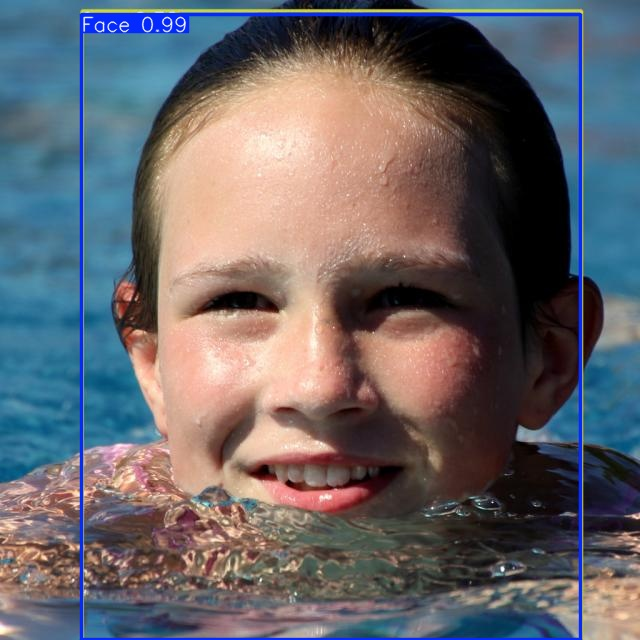

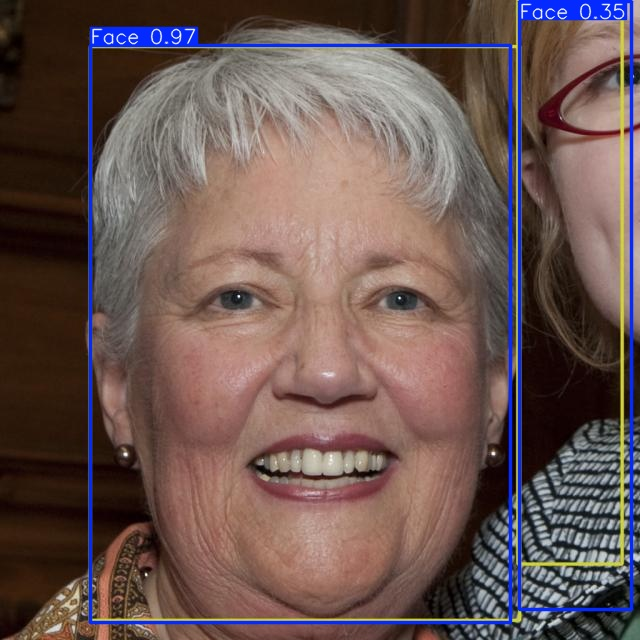

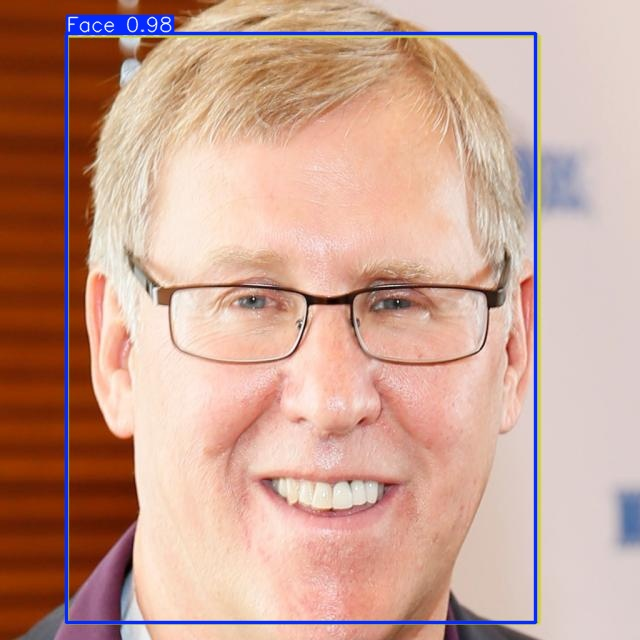

In [89]:
predicted_img_list_v11 = list(glob.glob("runs/detect/predict4/*.jpg"))

for image in predicted_img_list_v11[-5:]:
    display(Image(filename=image))

<h3>Testing Webcam for YoloV8</h3>

In [91]:
detect_face_webcam(model)

Webcam opened successfully. Press 'Esc' to exit.

0: 480x640 1 Face, 47.9ms
Speed: 3.7ms preprocess, 47.9ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Face, 25.2ms
Speed: 3.0ms preprocess, 25.2ms inference, 3.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Face, 27.1ms
Speed: 3.2ms preprocess, 27.1ms inference, 5.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Face, 26.9ms
Speed: 3.6ms preprocess, 26.9ms inference, 4.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Face, 27.5ms
Speed: 2.6ms preprocess, 27.5ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Face, 27.7ms
Speed: 2.6ms preprocess, 27.7ms inference, 4.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Face, 26.5ms
Speed: 3.0ms preprocess, 26.5ms inference, 4.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Face, 26.8ms
Speed: 2.7ms preprocess, 26.8ms inference, 3.4ms postpro

<h3>Testing Webcam for YoloV11</h3>

In [90]:
detect_face_webcam(model2)

Webcam opened successfully. Press 'Esc' to exit.

0: 480x640 1 Face, 111.6ms
Speed: 12.2ms preprocess, 111.6ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 Faces, 29.4ms
Speed: 5.6ms preprocess, 29.4ms inference, 5.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 Faces, 24.9ms
Speed: 3.1ms preprocess, 24.9ms inference, 3.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 Faces, 32.2ms
Speed: 2.9ms preprocess, 32.2ms inference, 3.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 Faces, 34.8ms
Speed: 3.2ms preprocess, 34.8ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 Faces, 32.2ms
Speed: 2.9ms preprocess, 32.2ms inference, 4.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 Faces, 30.7ms
Speed: 4.5ms preprocess, 30.7ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 Faces, 30.4ms
Speed: 3.6ms preprocess, 30.4ms inference, 4.2